In [1]:
import pandas as pd

df = pd.read_csv(r"E:\MDS\Projects\Major Project\Final_Project\Dataset\final dataset.csv")
df.head()

,DATASET,SERIES_CODE,OBS_MEASURE,COUNTRY,INDICATOR,FREQUENCY,SCALE,1995,1996,1997,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,IMF.RES:WEO(9.0.0),GBR.BCA_NGDPD.A,OBS_VALUE,United Kingdom,"Current account balance (credit less debit), P...",Annual,Units,-0.381,-0.264,-0.140,...,-5.022,-4.948,-5.448,-3.493,-3.927,-2.688,-2.934,-0.437,-2.102,-3.509
1,IMF.RES:WEO(9.0.0),USA.GGX_NGDP.A,OBS_VALUE,United States,"Expenditure, General government, Percent of GDP",Annual,Units,NaN,NaN,NaN,...,35.324,35.031,35.333,35.194,35.349,35.819,44.722,43.201,36.790,37.650
2,IMF.RES:WEO(9.0.0),AUT.BCA_NGDPD.A,OBS_VALUE,Austria,"Current account balance (credit less debit), P...",Annual,Units,-2.876,-2.854,-2.559,...,2.397,1.577,2.574,1.264,0.846,2.376,3.367,1.735,-0.862,1.341
3,IMF.RES:WEO(9.0.0),USA.GGXWDG_NGDP.A,OBS_VALUE,United States,"Gross debt, General government, Percent of GDP",Annual,Units,NaN,NaN,NaN,...,104.930,105.424,107.380,106.374,107.625,108.751,132.513,125.009,119.104,119.836
4,IMF.RES:WEO(9.0.0),GBR.GGX_NGDP.A,OBS_VALUE,United Kingdom,"Expenditure, General government, Percent of GDP",Annual,Units,37.631,35.716,34.891,...,41.184,40.425,39.632,39.155,38.871,38.763,49.987,45.753,44.099,44.829


In [2]:
df_long = df.melt(
    id_vars=["COUNTRY", "INDICATOR"],
    var_name="YEAR",
    value_name="VALUE"
)


In [3]:
df_long["YEAR"] = pd.to_numeric(df_long["YEAR"], errors="coerce")
df_long = df_long.dropna(subset=["YEAR"])
df_long["YEAR"] = df_long["YEAR"].astype(int)

In [4]:
df_panel = df_long.pivot_table(
    index=["COUNTRY", "YEAR"],
    columns="INDICATOR",
    values="VALUE"
).reset_index()

In [5]:
df_panel.head()

INDICATOR,COUNTRY,YEAR,"All Items, Consumer price index (CPI), Period average, percent change","Current account balance (credit less debit), Percent of GDP","Expenditure, General government, Percent of GDP","Exports of goods and services, Volume, Free on board (FOB), Percent change","Gross capital formation, Percent of GDP","Gross debt, General government, Percent of GDP","Gross domestic product (GDP), Constant prices, Percent change","Gross national savings, Percent of GDP","Imports of goods and services, Volume, Cost insurance freight (CIF), Percent change","Net lending (+) / net borrowing (-), General government, Percent of GDP","Revenue, General government, Percent of GDP",Unemployment rate
0,"Afghanistan, Islamic Republic of",2002,NaN,33.908,6.943,NaN,27.243,345.977,NaN,61.151,NaN,-0.098,6.845,NaN
1,"Afghanistan, Islamic Republic of",2003,35.663,29.616,11.927,49.541,30.102,270.602,8.692,59.718,36.222,-2.102,9.826,NaN
2,"Afghanistan, Islamic Republic of",2004,16.358,37.216,15.069,-8.436,35.354,244.967,0.671,72.57,-0.427,-2.393,12.676,NaN
3,"Afghanistan, Islamic Republic of",2005,10.569,30.226,15.651,41.968,37.048,206.356,11.83,67.274,55.01,-0.917,14.733,NaN
4,"Afghanistan, Islamic Republic of",2006,6.785,20.844,18.262,-6.919,29.489,22.985,5.361,50.333,-2.198,0.684,18.946,NaN


In [6]:
df_panel.columns

Index(['COUNTRY', 'YEAR',
       'All Items, Consumer price index (CPI), Period average, percent change',
       'Current account balance (credit less debit), Percent of GDP',
       'Expenditure, General government, Percent of GDP',
       'Exports of goods and services, Volume, Free on board (FOB), Percent change',
       'Gross capital formation, Percent of GDP',
       'Gross debt, General government, Percent of GDP',
       'Gross domestic product (GDP), Constant prices, Percent change',
       'Gross national savings, Percent of GDP',
       'Imports of goods and services, Volume, Cost insurance freight (CIF), Percent change',
       'Net lending (+) / net borrowing (-), General government, Percent of GDP',
       'Revenue, General government, Percent of GDP', 'Unemployment rate'],
      dtype='object', name='INDICATOR')

Renaming columns

In [7]:
df_panel.rename(columns={
    "All Items, Consumer price index (CPI), Period average, percent change": "Inflation",
    "Gross domestic product (GDP), Constant prices, percent change": "GDP_Growth",
    "Gross debt, General government, Percent of GDP": "Debt",
    "Net lending (+) / net borrowing (-), General government, Percent of GDP": "Fiscal_Balance",
    "Current account balance (credit less debit), Percent of GDP": "Current_Account",
    "Exports of goods and services, volume, Free on board (FOB), Percent change": "Exports",
    "Imports of goods and services, volume, Cost insurance freight (CIF), Percent change": "Imports",
    "Revenue, General government, Percent of GDP": "Revenue",
    "Expenditure, General government, Percent of GDP": "Expenditure",
    "Gross national savings, Percent of GDP": "Savings",
    "Gross capital formation, Percent of GDP": "Investment"
}, inplace=True)

In [8]:
df_panel.shape

(5584, 14)

In [9]:
df_panel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5584 entries, 0 to 5583
Data columns (total 14 columns):
 #   Column                                                                               Non-Null Count  Dtype 
---  ------                                                                               --------------  ----- 
 0   COUNTRY                                                                              5584 non-null   object
 1   YEAR                                                                                 5584 non-null   int64 
 2   Inflation                                                                            5524 non-null   object
 3   Current_Account                                                                      5376 non-null   object
 4   Expenditure                                                                          5330 non-null   object
 5   Exports of goods and services, Volume, Free on board (FOB), Percent change           4952 non-nul

In [10]:
df_panel.duplicated(subset=["COUNTRY","YEAR"]).sum()

np.int64(0)

In [11]:
df_panel = df_panel.drop_duplicates(subset=["COUNTRY","YEAR"])

In [12]:
df_panel = df_panel.sort_values(["COUNTRY","YEAR"])

In [13]:
for col in df_panel.columns[2:]:
    df_panel[col] = pd.to_numeric(df_panel[col], errors="coerce")

In [14]:
(df_panel.isnull().mean()*100).sort_values(ascending=False)

INDICATOR
Unemployment rate                                                                      43.159026
Savings                                                                                13.861032
Investment                                                                             12.786533
Imports of goods and services, Volume, Cost insurance freight (CIF), Percent change    11.747851
Exports of goods and services, Volume, Free on board (FOB), Percent change             11.318052
Debt                                                                                    9.133238
Fiscal_Balance                                                                          4.656160
Expenditure                                                                             4.548711
Revenue                                                                                 3.868195
Current_Account                                                                         3.724928
Inflation           

In [15]:
df_panel = df_panel.drop(columns=["Unemployment rate"])

In [16]:
df_panel.columns = df_panel.columns.str.strip()

df_panel.rename(columns={
    "Gross domestic product (GDP), Constant prices, Percent change": "GDP_Growth",
    "Exports of goods and services, Volume, Free on board (FOB), Percent change": "Exports",
    "Imports of goods and services, Volume, Cost insurance freight (CIF), Percent change": "Imports",
    "Gross national savings, Percent of GDP": "Savings",
    "Gross capital formation, Percent of GDP": "Investment",
    "Gross debt, General government, Percent of GDP": "Debt"
}, inplace=True)

In [17]:
df_panel.columns.tolist()

['COUNTRY',
 'YEAR',
 'Inflation',
 'Current_Account',
 'Expenditure',
 'Exports',
 'Investment',
 'Debt',
 'GDP_Growth',
 'Savings',
 'Imports',
 'Fiscal_Balance',
 'Revenue']

In [18]:
cols_to_interpolate = [
    "Inflation",
    "Current_Account",
    "Expenditure",
    "Exports",
    "Imports",
    "Savings",
    "Investment",
    "Debt",
    "Fiscal_Balance",
    "Revenue",
]

df_panel[cols_to_interpolate] = (
    df_panel.groupby("COUNTRY")[cols_to_interpolate]
    .transform(lambda x: x.interpolate(method="linear"))
)

df_panel[cols_to_interpolate] = (
    df_panel.groupby("COUNTRY")[cols_to_interpolate]
    .transform(lambda x: x.ffill().bfill())
)

In [19]:
df_panel = df_panel.dropna(subset=["GDP_Growth"])

In [20]:
(df_panel[cols_to_interpolate].isnull().mean() * 100)

INDICATOR
Inflation           0.000000
Current_Account     0.521864
Expenditure         0.000000
Exports             8.313838
Imports             8.781717
Savings            11.588987
Investment         10.311319
Debt                1.133705
Fiscal_Balance      0.000000
Revenue             0.000000
dtype: float64

In [21]:
df_panel[cols_to_interpolate] = (
    df_panel.groupby("COUNTRY")[cols_to_interpolate]
    .transform(lambda x: x.ffill().bfill())
)

In [22]:
(df_panel[cols_to_interpolate].isnull().mean() * 100)

INDICATOR
Inflation           0.000000
Current_Account     0.521864
Expenditure         0.000000
Exports             8.313838
Imports             8.781717
Savings            11.588987
Investment         10.311319
Debt                1.133705
Fiscal_Balance      0.000000
Revenue             0.000000
dtype: float64

~Data Preparation~

In [23]:
country_missing = df_panel.groupby("COUNTRY")[cols_to_interpolate].apply(
    lambda x: x.isnull().mean().mean()
)

country_missing.sort_values(ascending=False)
 

COUNTRY
Somalia                                0.5
Nauru, Republic of                     0.4
Micronesia, Federated States of        0.4
Liechtenstein, Principality of         0.4
Andorra, Principality of               0.4
                                      ... 
Uzbekistan, Republic of                0.0
Vietnam                                0.0
Venezuela, República Bolivariana de    0.0
Yemen, Republic of                     0.0
Zambia                                 0.0
Length: 197, dtype: float64

In [24]:
countries_to_remove = country_missing[country_missing >= 0.30]

countries_to_remove.sort_values(ascending=False)

COUNTRY
Somalia                                                            0.5
Andorra, Principality of                                           0.4
Liechtenstein, Principality of                                     0.4
Micronesia, Federated States of                                    0.4
Nauru, Republic of                                                 0.4
Tuvalu                                                             0.4
Samoa                                                              0.4
Puerto Rico                                                        0.4
Macao Special Administrative Region, People's Republic of China    0.4
Zimbabwe                                                           0.4
Aruba, Kingdom of the Netherlands                                  0.3
Fiji, Republic of                                                  0.3
Iraq                                                               0.3
Marshall Islands, Republic of the                                  0.

In [25]:
countries_to_keep = country_missing[country_missing < 0.30]

countries_to_keep.sort_values()

COUNTRY
Afghanistan, Islamic Republic of    0.0
Albania                             0.0
Algeria                             0.0
Angola                              0.0
Antigua and Barbuda                 0.0
                                   ... 
Kiribati                            0.2
Papua New Guinea                    0.2
South Sudan, Republic of            0.2
Tonga                               0.2
Turkmenistan                        0.2
Length: 180, dtype: float64

In [26]:
df_panel = df_panel[
    df_panel["COUNTRY"].isin(
        country_missing[country_missing < 0.30].index
    )
]

In [27]:
valid_countries = country_missing[country_missing < 0.30].index

df_panel = df_panel[df_panel["COUNTRY"].isin(valid_countries)]

In [28]:
df_panel.head()

INDICATOR,COUNTRY,YEAR,Inflation,Current_Account,Expenditure,Exports,Investment,Debt,GDP_Growth,Savings,Imports,Fiscal_Balance,Revenue
1,"Afghanistan, Islamic Republic of",2003,35.663,29.616,11.927,49.541,30.102,270.602,8.692,59.718,36.222,-2.102,9.826
2,"Afghanistan, Islamic Republic of",2004,16.358,37.216,15.069,-8.436,35.354,244.967,0.671,72.570,-0.427,-2.393,12.676
3,"Afghanistan, Islamic Republic of",2005,10.569,30.226,15.651,41.968,37.048,206.356,11.830,67.274,55.010,-0.917,14.733
4,"Afghanistan, Islamic Republic of",2006,6.785,20.844,18.262,-6.919,29.489,22.985,5.361,50.333,-2.198,0.684,18.946
5,"Afghanistan, Islamic Republic of",2007,8.681,63.390,21.448,-11.904,55.852,20.137,13.340,119.243,-10.210,-2.462,18.986


In [29]:
df_panel["COUNTRY"].nunique()

180

In [30]:
(df_panel[cols_to_interpolate].isnull().mean() * 100)

INDICATOR
Inflation          0.000000
Current_Account    0.000000
Expenditure        0.000000
Exports            1.362133
Imports            1.362133
Savings            5.409613
Investment         6.090679
Debt               0.564312
Fiscal_Balance     0.000000
Revenue            0.000000
dtype: float64

In [31]:
df_panel = df_panel.sort_values(["COUNTRY", "YEAR"])
df_panel = df_panel.reset_index(drop=True)

In [32]:
df_panel.head()

INDICATOR,COUNTRY,YEAR,Inflation,Current_Account,Expenditure,Exports,Investment,Debt,GDP_Growth,Savings,Imports,Fiscal_Balance,Revenue
0,"Afghanistan, Islamic Republic of",2003,35.663,29.616,11.927,49.541,30.102,270.602,8.692,59.718,36.222,-2.102,9.826
1,"Afghanistan, Islamic Republic of",2004,16.358,37.216,15.069,-8.436,35.354,244.967,0.671,72.570,-0.427,-2.393,12.676
2,"Afghanistan, Islamic Republic of",2005,10.569,30.226,15.651,41.968,37.048,206.356,11.830,67.274,55.010,-0.917,14.733
3,"Afghanistan, Islamic Republic of",2006,6.785,20.844,18.262,-6.919,29.489,22.985,5.361,50.333,-2.198,0.684,18.946
4,"Afghanistan, Islamic Republic of",2007,8.681,63.390,21.448,-11.904,55.852,20.137,13.340,119.243,-10.210,-2.462,18.986


In [33]:

lag_cols = ["Inflation","Debt","Fiscal_Balance",
            "Current_Account","Exports","Imports","Revenue",
            "Expenditure","Savings","Investment"]
for col in lag_cols:
    df_panel[f"{col}_lag1"] = df_panel.groupby("COUNTRY")[col].shift(1)
df_panel = df_panel.dropna(subset=[f"{col}_lag1" for col in lag_cols])

df_panel.to_csv("df_panel_clean.csv", index=False)
print(df_panel.shape) 



(4484, 23)


In [34]:
 df_panel = df_panel.dropna(subset=[f"{col}_lag1" for col in lag_cols]) 

In [35]:
df_panel.shape

(4484, 23)

In [36]:
df_panel.head()

INDICATOR,COUNTRY,YEAR,Inflation,Current_Account,Expenditure,Exports,Investment,Debt,GDP_Growth,Savings,...,Inflation_lag1,Debt_lag1,Fiscal_Balance_lag1,Current_Account_lag1,Exports_lag1,Imports_lag1,Revenue_lag1,Expenditure_lag1,Savings_lag1,Investment_lag1
1,"Afghanistan, Islamic Republic of",2004,16.358,37.216,15.069,-8.436,35.354,244.967,0.671,72.570,...,35.663,270.602,-2.102,29.616,49.541,36.222,9.826,11.927,59.718,30.102
2,"Afghanistan, Islamic Republic of",2005,10.569,30.226,15.651,41.968,37.048,206.356,11.830,67.274,...,16.358,244.967,-2.393,37.216,-8.436,-0.427,12.676,15.069,72.570,35.354
3,"Afghanistan, Islamic Republic of",2006,6.785,20.844,18.262,-6.919,29.489,22.985,5.361,50.333,...,10.569,206.356,-0.917,30.226,41.968,55.010,14.733,15.651,67.274,37.048
4,"Afghanistan, Islamic Republic of",2007,8.681,63.390,21.448,-11.904,55.852,20.137,13.340,119.243,...,6.785,22.985,0.684,20.844,-6.919,-2.198,18.946,18.262,50.333,29.489
5,"Afghanistan, Islamic Republic of",2008,26.419,33.769,20.899,-6.742,30.222,19.057,3.863,63.990,...,8.681,20.137,-2.462,63.390,-11.904,-10.210,18.986,21.448,119.243,55.852


In [37]:
 df_before_lag = pd.read_csv(r"E:\MDS\Projects\Major Project\Final_Project\Dataset\df_panel.csv") 

In [38]:
original_countries = set(df_before_lag["COUNTRY"].unique())
after_lag_countries = set(df_panel["COUNTRY"].unique())

removed_countries = original_countries - after_lag_countries

removed_countries


{'Andorra, Principality of',
 'Aruba, Kingdom of the Netherlands',
 'Brunei Darussalam',
 'Fiji, Republic of',
 'Iraq',
 'Kiribati',
 'Kuwait',
 "Lao People's Democratic Republic",
 'Lebanon',
 'Liberia',
 'Libya',
 'Liechtenstein, Principality of',
 "Macao Special Administrative Region, People's Republic of China",
 'Marshall Islands, Republic of the',
 'Micronesia, Federated States of',
 'Nauru, Republic of',
 'Nepal',
 'North Macedonia, Republic of',
 'Palau, Republic of',
 'Papua New Guinea',
 'Puerto Rico',
 'Qatar',
 'Samoa',
 'San Marino, Republic of',
 'Somalia',
 'South Sudan, Republic of',
 'Sudan',
 'Timor-Leste, Democratic Republic of',
 'Tonga',
 'Trinidad and Tobago',
 'Turkmenistan',
 'Tuvalu',
 'Vanuatu',
 'West Bank and Gaza',
 'Zimbabwe'}

In [39]:
df_panel.head()

INDICATOR,COUNTRY,YEAR,Inflation,Current_Account,Expenditure,Exports,Investment,Debt,GDP_Growth,Savings,...,Inflation_lag1,Debt_lag1,Fiscal_Balance_lag1,Current_Account_lag1,Exports_lag1,Imports_lag1,Revenue_lag1,Expenditure_lag1,Savings_lag1,Investment_lag1
1,"Afghanistan, Islamic Republic of",2004,16.358,37.216,15.069,-8.436,35.354,244.967,0.671,72.570,...,35.663,270.602,-2.102,29.616,49.541,36.222,9.826,11.927,59.718,30.102
2,"Afghanistan, Islamic Republic of",2005,10.569,30.226,15.651,41.968,37.048,206.356,11.830,67.274,...,16.358,244.967,-2.393,37.216,-8.436,-0.427,12.676,15.069,72.570,35.354
3,"Afghanistan, Islamic Republic of",2006,6.785,20.844,18.262,-6.919,29.489,22.985,5.361,50.333,...,10.569,206.356,-0.917,30.226,41.968,55.010,14.733,15.651,67.274,37.048
4,"Afghanistan, Islamic Republic of",2007,8.681,63.390,21.448,-11.904,55.852,20.137,13.340,119.243,...,6.785,22.985,0.684,20.844,-6.919,-2.198,18.946,18.262,50.333,29.489
5,"Afghanistan, Islamic Republic of",2008,26.419,33.769,20.899,-6.742,30.222,19.057,3.863,63.990,...,8.681,20.137,-2.462,63.390,-11.904,-10.210,18.986,21.448,119.243,55.852


Stationarity test

In [40]:

from statsmodels.tsa.stattools import adfuller, kpss
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

cols_to_test = [
    "GDP_Growth", "Inflation", "Debt",
    "Fiscal_Balance", "Current_Account", "Exports",
    "Imports", "Revenue", "Expenditure", "Savings", "Investment"
]

results = []

for col in cols_to_test:
    adf_stats, kpss_stats = [], []

    for country, grp in df_panel.groupby("COUNTRY"):
        series = grp[col].dropna()
        if len(series) < 8:   # need minimum observations
            continue

        # ADF: H0 = unit root (non-stationary)
        try:
            adf_p = adfuller(series, autolag="AIC")[1]
            adf_stats.append(adf_p)
        except:
            pass

        # KPSS: H0 = stationary (opposite null)
        try:
            kpss_p = kpss(series, regression="c", nlags="auto")[1]
            kpss_stats.append(kpss_p)
        except:
            pass

    results.append({
        "Column"          : col,
        "ADF_pct_reject"  : np.mean(np.array(adf_stats) < 0.05) * 100,  # % countries where H0 rejected = stationary
        "KPSS_pct_reject" : np.mean(np.array(kpss_stats) < 0.05) * 100, # % countries where H0 rejected = non-stationary
        "ADF_median_p"    : np.median(adf_stats),
        "KPSS_median_p"   : np.median(kpss_stats)
    })

stationarity_df = pd.DataFrame(results)
print(stationarity_df.to_string(index=False))


         Column  ADF_pct_reject  KPSS_pct_reject  ADF_median_p  KPSS_median_p
     GDP_Growth       77.160494        12.345679      0.001017       0.100000
      Inflation       59.876543        14.197531      0.029209       0.100000
           Debt       17.283951        53.086420      0.508248       0.045267
 Fiscal_Balance       38.888889        22.839506      0.084326       0.100000
Current_Account       29.629630        27.777778      0.171880       0.100000
        Exports       82.716049        11.728395      0.000515       0.100000
        Imports       81.481481        10.493827      0.000297       0.100000
        Revenue       25.925926        49.382716      0.242242       0.053539
    Expenditure       24.074074        50.000000      0.260866       0.049827
        Savings       27.160494        39.506173      0.211030       0.092946
     Investment       29.629630        38.271605      0.198694       0.098929


In [41]:

non_stationary_cols = ["Debt", "Expenditure", "Revenue", 
                        "Savings", "Investment"]

# First difference within each country
for col in non_stationary_cols:
    df_panel[f"{col}_diff"] = df_panel.groupby("COUNTRY")[col]\
        .transform(lambda x: x.diff())

# Verify — re-run ADF on differenced series
from statsmodels.tsa.stattools import adfuller
import numpy as np

for col in non_stationary_cols:
    pvals = []
    for country, grp in df_panel.groupby("COUNTRY"):
        s = grp[f"{col}_diff"].dropna()
        if len(s) >= 8:
            try:
                pvals.append(adfuller(s, autolag="AIC")[1])
            except:
                pass
    pct = np.mean(np.array(pvals) < 0.05) * 100
    print(f"{col}_diff → {pct:.1f}% stationary after differencing")


Debt_diff → 69.1% stationary after differencing
Expenditure_diff → 84.0% stationary after differencing
Revenue_diff → 79.6% stationary after differencing
Savings_diff → 72.2% stationary after differencing
Investment_diff → 84.0% stationary after differencing


In [42]:
# Define your final feature columns
stationary_cols = [
    "Inflation", "Exports", "Imports",
    "Fiscal_Balance", "Current_Account", "GDP_Growth"
]

differenced_cols = [
    "Debt_diff", "Expenditure_diff",
    "Revenue_diff", "Savings_diff", "Investment_diff"
]

all_feature_cols = stationary_cols[:-1] + differenced_cols  
# exclude GDP_Growth from features — it is the target

# Build lags (single block — do not repeat)
for col in all_feature_cols:
    df_panel[f"{col}_lag1"] = df_panel.groupby("COUNTRY")[col]\
        .transform(lambda x: x.shift(1))

lag_feature_cols = [f"{col}_lag1" for col in all_feature_cols]

# Drop ONLY where target is missing
df_panel = df_panel.dropna(subset=["GDP_Growth"])

# For lag/diff NaNs — drop only the structural first-year rows
# These are rows where ALL lag cols are NaN simultaneously
# i.e. the genuine first year per country
df_panel = df_panel.dropna(subset=lag_feature_cols, how="all")

# Any remaining scattered NaNs → year-wise median
df_panel[lag_feature_cols] = df_panel.groupby("YEAR")[lag_feature_cols]\
    .transform(lambda x: x.fillna(x.median()))

# Final verification
print(f"Countries: {df_panel['COUNTRY'].nunique()}")
print(f"Rows: {df_panel.shape[0]}")
print(f"Remaining NaNs: {df_panel[lag_feature_cols].isnull().sum().sum()}")

Countries: 162
Rows: 4322
Remaining NaNs: 770


In [43]:
lag_cols = [col for col in df_panel.columns if "_lag1" in col]

df_panel = df_panel.dropna(subset=lag_cols)

In [44]:

# How many years does each country have after cleaning?
country_counts = df_panel.groupby("COUNTRY")["YEAR"].count().sort_values()

print("Countries with fewer than 10 observations:")
print(country_counts[country_counts < 10])

print(f"\nTotal countries remaining: {df_panel['COUNTRY'].nunique()}")
print(f"Total rows: {df_panel.shape[0]}")
print(f"Year range: {df_panel['YEAR'].min()} – {df_panel['YEAR'].max()}")

# Average years per country
print(f"\nAvg years per country: {country_counts.mean():.1f}")
print(f"Min: {country_counts.min()}, Max: {country_counts.max()}")

Countries with fewer than 10 observations:
Series([], Name: YEAR, dtype: int64)

Total countries remaining: 162
Total rows: 4168
Year range: 1998 – 2023

Avg years per country: 25.7
Min: 13, Max: 26


In [45]:
# Fill the 154 structural NaNs with year-wise cross-sectional median
df_panel[lag_feature_cols] = df_panel.groupby("YEAR")[lag_feature_cols]\
    .transform(lambda x: x.fillna(x.median()))

# Verify
print(df_panel[lag_feature_cols].isnull().sum().sum())  # should be 0
print(df_panel["COUNTRY"].nunique())                    # should be ~165-170

0
162


In [46]:
df_panel.isnull().sum().sort_values(ascending=False).head(10)

INDICATOR
COUNTRY            0
YEAR               0
Inflation          0
Current_Account    0
Expenditure        0
Exports            0
Investment         0
Debt               0
GDP_Growth         0
Savings            0
dtype: int64

In [47]:
df_panel.head()

INDICATOR,COUNTRY,YEAR,Inflation,Current_Account,Expenditure,Exports,Investment,Debt,GDP_Growth,Savings,...,Debt_diff,Expenditure_diff,Revenue_diff,Savings_diff,Investment_diff,Debt_diff_lag1,Expenditure_diff_lag1,Revenue_diff_lag1,Savings_diff_lag1,Investment_diff_lag1
2,"Afghanistan, Islamic Republic of",2005,10.569,30.226,15.651,41.968,37.048,206.356,11.830,67.274,...,-38.611,0.582,2.057,-5.296,1.694,-1.716,-0.452,0.288,0.590,0.486
3,"Afghanistan, Islamic Republic of",2006,6.785,20.844,18.262,-6.919,29.489,22.985,5.361,50.333,...,-183.371,2.611,4.213,-16.941,-7.559,-38.611,0.582,2.057,-5.296,1.694
4,"Afghanistan, Islamic Republic of",2007,8.681,63.390,21.448,-11.904,55.852,20.137,13.340,119.243,...,-2.848,3.186,0.040,68.910,26.363,-183.371,2.611,4.213,-16.941,-7.559
5,"Afghanistan, Islamic Republic of",2008,26.419,33.769,20.899,-6.742,30.222,19.057,3.863,63.990,...,-1.080,-0.549,-1.950,-55.253,-25.630,-2.848,3.186,0.040,68.910,26.363
6,"Afghanistan, Islamic Republic of",2009,-6.811,41.587,21.151,30.013,36.503,16.247,20.585,78.090,...,-2.810,0.252,2.355,14.100,6.281,-1.080,-0.549,-1.950,-55.253,-25.630


In [48]:
# Columns to compute rolling stats on
# Use original indicators (not diff, not lag — rolling on raw series)
roll_cols = [
    "Inflation", "GDP_Growth", "Exports", "Imports",
    "Fiscal_Balance", "Current_Account",
    "Debt", "Expenditure", "Revenue", "Savings", "Investment"
]

windows = [3, 5]  # 3-year and 5-year rolling windows

for col in roll_cols:
    for w in windows:
        # Rolling mean — captures trend/momentum
        df_panel[f"{col}_rollmean{w}"] = (
            df_panel.groupby("COUNTRY")[col]
            .transform(lambda x: x.shift(1).rolling(window=w, min_periods=2).mean())
        )
        
        # Rolling std — captures volatility (key for instability index)
        df_panel[f"{col}_rollstd{w}"] = (
            df_panel.groupby("COUNTRY")[col]
            .transform(lambda x: x.shift(1).rolling(window=w, min_periods=2).std())
        )

print(f"New columns added: {len(roll_cols) * len(windows) * 2}")
print(f"Total columns now: {df_panel.shape[1]}")

New columns added: 44
Total columns now: 77


In [49]:
roll_stat_cols = [c for c in df_panel.columns 
                  if "rollmean" in c or "rollstd" in c]

# Year-wise median fill
df_panel[roll_stat_cols] = df_panel.groupby("YEAR")[roll_stat_cols]\
    .transform(lambda x: x.fillna(x.median()))

# Country-wise ffill/bfill for any remaining
df_panel[roll_stat_cols] = df_panel.groupby("COUNTRY")[roll_stat_cols]\
    .transform(lambda x: x.ffill().bfill())

# Global median as last resort
for col in roll_stat_cols:
    df_panel[col] = df_panel[col].fillna(df_panel[col].median())

print(f"Missing in roll stats: {df_panel[roll_stat_cols].isnull().sum().sum()}")

Missing in roll stats: 0


Layer 1

In [50]:
from scipy.stats import mstats
from sklearn.preprocessing import RobustScaler, MinMaxScaler
import numpy as np

instability_indicators = [
    "Inflation", "GDP_Growth", "Fiscal_Balance", 
    "Debt", "Current_Account"
]

# --- Component 1: Z-score ---
for col in instability_indicators:
    df_panel[f"{col}_zscore"] = df_panel.groupby("COUNTRY")[col]\
        .transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))

# --- Component 2: Volatility (rolling std 3yr) ---
# Already exists from rolling stats step

# --- Component 3: Shock (abs year-on-year change) ---
for col in instability_indicators:
    df_panel[f"{col}_shock"] = df_panel.groupby("COUNTRY")[col]\
        .transform(lambda x: x.diff().abs())

zscore_cols     = [f"{col}_zscore"   for col in instability_indicators]
volatility_cols = [f"{col}_rollstd3" for col in instability_indicators]
shock_cols      = [f"{col}_shock"    for col in instability_indicators]
all_component_cols = zscore_cols + volatility_cols + shock_cols

# --- Winsorize at 5/95 percentile to remove micro-economy outliers ---
for col in all_component_cols:
    arr = df_panel[col].fillna(0).values
    df_panel[col] = mstats.winsorize(arr, limits=[0.05, 0.05])

# --- RobustScaler then clip to 0-1 ---
scaler = RobustScaler()
df_panel[all_component_cols] = scaler.fit_transform(
    df_panel[all_component_cols]
)
df_panel[all_component_cols] = df_panel[all_component_cols].clip(0, 1)

# --- Composite index with revised weights ---
df_panel["z_component"]     = df_panel[zscore_cols].abs().mean(axis=1)
df_panel["vol_component"]   = df_panel[volatility_cols].mean(axis=1)
df_panel["shock_component"] = df_panel[shock_cols].mean(axis=1)

w1, w2, w3 = 0.30, 0.40, 0.30
df_panel["Instability_Index"] = (
    w1 * df_panel["z_component"] +
    w2 * df_panel["vol_component"] +
    w3 * df_panel["shock_component"]
)

# --- Final 0-100 scaling ---
df_panel["Instability_Index"] = MinMaxScaler(feature_range=(0, 100))\
    .fit_transform(df_panel[["Instability_Index"]])

# --- Re-run validation ---
validation_cases = [
    ("Greece",                          2010),
    ("Argentina",                       2001),
    ("United States",                   2009),
    ("Ireland",                         2010),
    ("Venezuela, República Bolivariana de", 2016),
]

print("=== Validation after fix ===")
for country, year in validation_cases:
    row = df_panel[
        (df_panel["COUNTRY"] == country) &
        (df_panel["YEAR"] == year)
    ]["Instability_Index"]
    if not row.empty:
        print(f"{country} {year}: {row.values[0]:.1f} / 100")
    else:
        print(f"{country} {year}: not in panel")

print("\n=== Top 20 most unstable ===")
print(
    df_panel[["COUNTRY", "YEAR", "Instability_Index"]]
    .sort_values("Instability_Index", ascending=False)
    .head(20)
    .to_string(index=False)
)

=== Validation after fix ===
Greece 2010: 50.6 / 100
Argentina 2001: 18.9 / 100
United States 2009: 36.3 / 100
Ireland 2010: 59.8 / 100
Venezuela, República Bolivariana de 2016: 63.0 / 100

=== Top 20 most unstable ===
                                      COUNTRY  YEAR  Instability_Index
                           Russian Federation  1999         100.000000
                           Russian Federation  2000          99.494899
                                    St. Lucia  2022          95.492779
                                   Cabo Verde  2022          94.430834
                                   Cabo Verde  2023          91.733863
                                    Argentina  2003          91.575828
                                     Suriname  2021          90.916840
São Tomé and Príncipe, Democratic Republic of  2007          89.300522
                        Eritrea, The State of  2015          89.123006
                        Eritrea, The State of  2018          88.682944


In [51]:
# Stability tiers on the final index
df_panel["Stability_Category"] = pd.cut(
    df_panel["Instability_Index"],
    bins=[0, 25, 50, 75, 100],
    labels=["Stable", "Moderate", "Unstable", "Crisis"]
)

print(df_panel["Stability_Category"].value_counts())
print(f"\nCrisis rate: {(df_panel['Stability_Category'] == 'Crisis').mean()*100:.1f}%")

# Save checkpoint
df_panel.to_csv("df_panel_with_instability.csv", index=False)
print(f"\nFinal shape: {df_panel.shape}")
print(f"Countries: {df_panel['COUNTRY'].nunique()}")

Stability_Category
Moderate    1732
Stable      1631
Unstable     717
Crisis        87
Name: count, dtype: int64

Crisis rate: 2.1%

Final shape: (4168, 92)
Countries: 162


count    4168.000000
mean       32.862802
std        18.620513
min         0.000000
25%        17.464149
50%        30.314063
75%        45.380126
max       100.000000
Name: Instability_Index, dtype: float64

Percentiles:
0.25    17.464149
0.50    30.314063
0.75    45.380126
0.90    59.189012
0.95    67.067869
Name: Instability_Index, dtype: float64


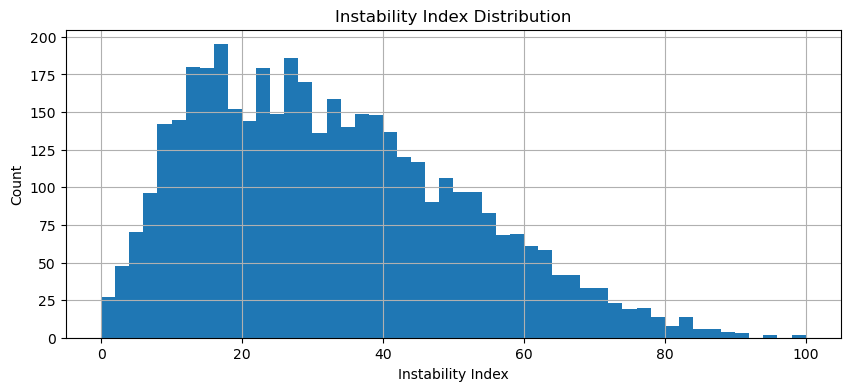

In [52]:
import matplotlib.pyplot as plt

print(df_panel["Instability_Index"].describe())
print(f"\nPercentiles:")
print(df_panel["Instability_Index"].quantile([0.25, 0.50, 0.75, 0.90, 0.95]))

df_panel["Instability_Index"].hist(bins=50, figsize=(10,4))
plt.title("Instability Index Distribution")
plt.xlabel("Instability Index")
plt.ylabel("Count")
plt.show()

In [53]:
# Percentile-based categorization
p25 = df_panel["Instability_Index"].quantile(0.25)
p50 = df_panel["Instability_Index"].quantile(0.50)
p75 = df_panel["Instability_Index"].quantile(0.75)

print(f"Thresholds — Stable: 0–{p25:.1f} | Moderate: {p25:.1f}–{p50:.1f} | "
      f"Unstable: {p50:.1f}–{p75:.1f} | Crisis: {p75:.1f}–100")

df_panel["Stability_Category"] = pd.cut(
    df_panel["Instability_Index"],
    bins=[0, p25, p50, p75, 100],
    labels=["Stable", "Moderate", "Unstable", "Crisis"],
    include_lowest=True
)

print(df_panel["Stability_Category"].value_counts())
print(f"Crisis rate: {(df_panel['Stability_Category'] == 'Crisis').mean()*100:.1f}%")

Thresholds — Stable: 0–17.5 | Moderate: 17.5–30.3 | Unstable: 30.3–45.4 | Crisis: 45.4–100
Stability_Category
Stable      1042
Moderate    1042
Unstable    1042
Crisis      1042
Name: count, dtype: int64
Crisis rate: 25.0%


In [54]:
# Top 20% = Crisis, next 30% = Unstable, next 30% = Moderate, bottom 20% = Stable
p20 = df_panel["Instability_Index"].quantile(0.20)
p50 = df_panel["Instability_Index"].quantile(0.50)
p80 = df_panel["Instability_Index"].quantile(0.80)

df_panel["Stability_Category"] = pd.cut(
    df_panel["Instability_Index"],
    bins=[0, p20, p50, p80, 100],
    labels=["Stable", "Moderate", "Unstable", "Crisis"],
    include_lowest=True
)

print(df_panel["Stability_Category"].value_counts())
print(f"Crisis rate: {(df_panel['Stability_Category'] == 'Crisis').mean()*100:.1f}%")

# Create binary EWS label (Unstable + Crisis = at-risk)
df_panel["Crisis_Flag"] = (
    df_panel["Stability_Category"].isin(["Crisis"])
).astype(int)

print(f"\nBinary crisis flag rate: {df_panel['Crisis_Flag'].mean()*100:.1f}%")

Stability_Category
Unstable    1250
Moderate    1249
Stable       835
Crisis       834
Name: count, dtype: int64
Crisis rate: 20.0%

Binary crisis flag rate: 20.0%


In [55]:
df_panel.to_csv("df_panel_with_instability.csv", index=False)
print("Checkpoint saved")
print(f"Shape: {df_panel.shape}")
print(f"Countries: {df_panel['COUNTRY'].nunique()}")

Checkpoint saved
Shape: (4168, 93)
Countries: 162


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [57]:
df = pd.read_csv(r"E:\MDS\Projects\Major Project\Dataset\df_panel_with_instability.csv")
 
lag_feature_cols = [
    "Inflation_lag1", "Exports_lag1", "Imports_lag1",
    "Fiscal_Balance_lag1", "Current_Account_lag1",
    "Debt_diff_lag1", "Expenditure_diff_lag1", "Revenue_diff_lag1",
    "Savings_diff_lag1", "Investment_diff_lag1"
]
 
# Plot style
plt.rcParams.update({
    "figure.facecolor": "#F9F9F7",
    "axes.facecolor":   "#F9F9F7",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#E5E5E0",
    "grid.linewidth":   0.6,
    "font.family":      "sans-serif",
    "font.size":        11,
})
BLUE   = "#2E5090"
AMBER  = "#C9720F"
RED    = "#A32D2D"
GREEN  = "#3B6D11"
TEAL   = "#0F6E56"
GRAY   = "#5F5E5A"


SECTION 1 — TARGET VARIABLE: GDP_Growth
count    4168.000
mean        3.614
std         5.142
min       -36.392
25%         1.664
50%         3.792
75%         5.908
max       110.505
Name: GDP_Growth, dtype: float64

Skewness : 2.400
Kurtosis : 59.311

Top 10 GDP Growth (highest):
                       COUNTRY  YEAR  GDP_Growth
Equatorial Guinea, Republic of  2000     110.505
                        Guyana  2022      63.334
Equatorial Guinea, Republic of  2001      60.023
                        Guyana  2020      43.480
                      Maldives  2021      37.508
       Azerbaijan, Republic of  2006      34.466
                        Guyana  2023      33.769
                          Chad  2004      33.629
         Eritrea, The State of  2014      30.934
Equatorial Guinea, Republic of  2004      30.391

Top 10 GDP Collapse (lowest):
                            COUNTRY  YEAR  GDP_Growth
           Central African Republic  2013     -36.392
                           Maldives  2

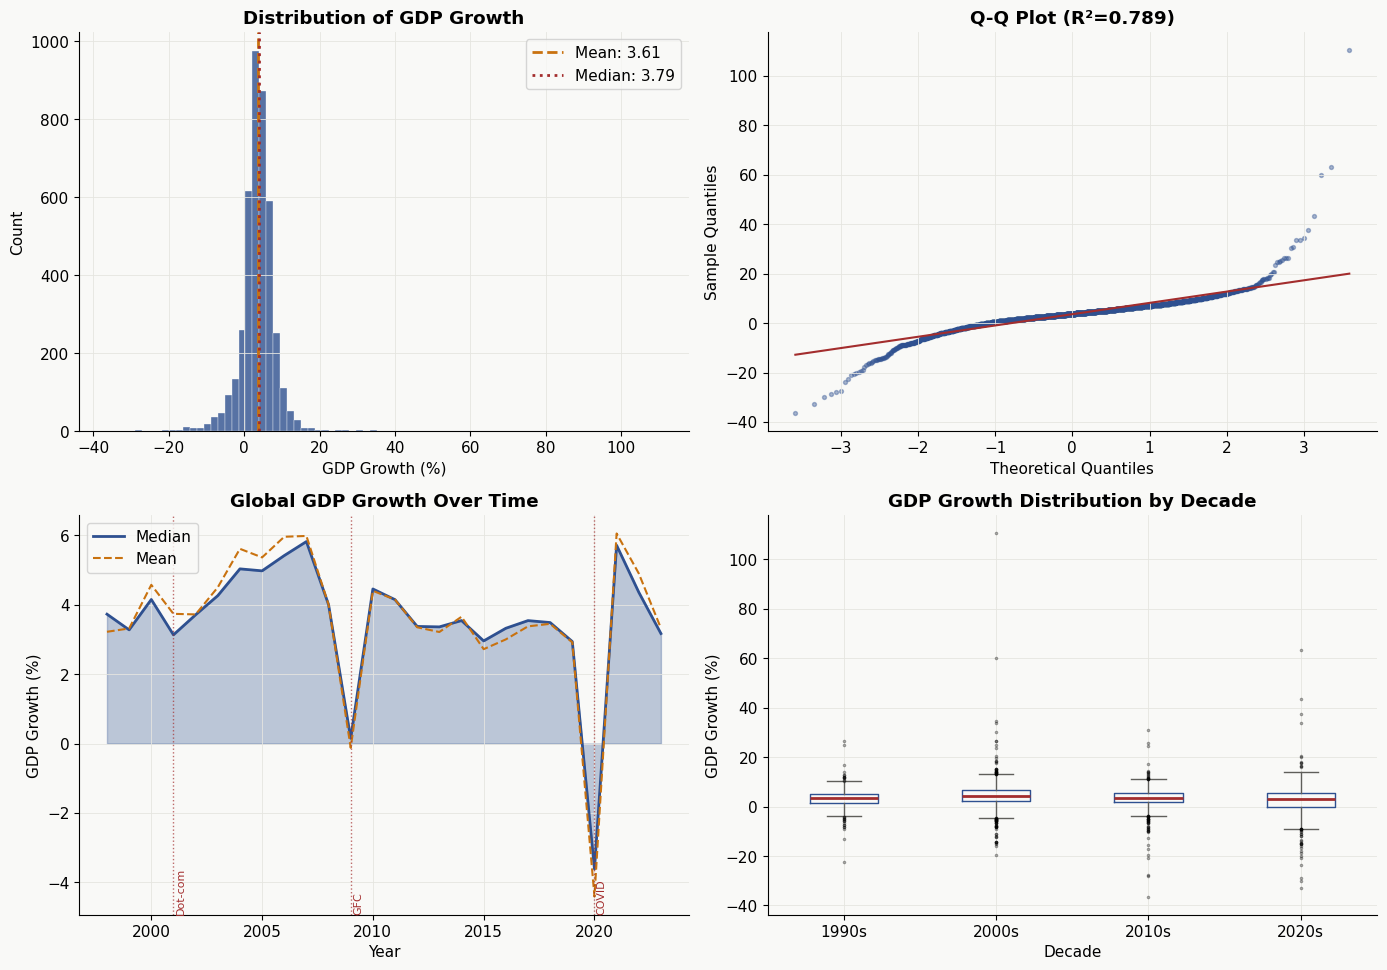

→ Saved: eda_1_gdp_growth.png

SECTION 2 — FEATURE RELATIONSHIPS WITH GDP_GROWTH

Correlation of lag features with GDP_Growth:
Imports_lag1             0.128
Inflation_lag1          -0.120
Debt_diff_lag1          -0.102
Exports_lag1             0.100
Savings_diff_lag1        0.068
Fiscal_Balance_lag1      0.043
Revenue_diff_lag1        0.029
Investment_diff_lag1    -0.012
Expenditure_diff_lag1   -0.009
Current_Account_lag1    -0.001

VIF Scores (>10 = multicollinearity concern):
        Feature  VIF Flag
      Inflation 1.01 ✅ OK
        Exports 1.37 ✅ OK
        Imports 1.52 ✅ OK
 Fiscal_Balance 1.50 ✅ OK
Current_Account 1.31 ✅ OK
        Debt(d) 1.21 ✅ OK
 Expenditure(d) 1.19 ✅ OK
     Revenue(d) 1.36 ✅ OK
     Savings(d) 1.36 ✅ OK
  Investment(d) 1.29 ✅ OK


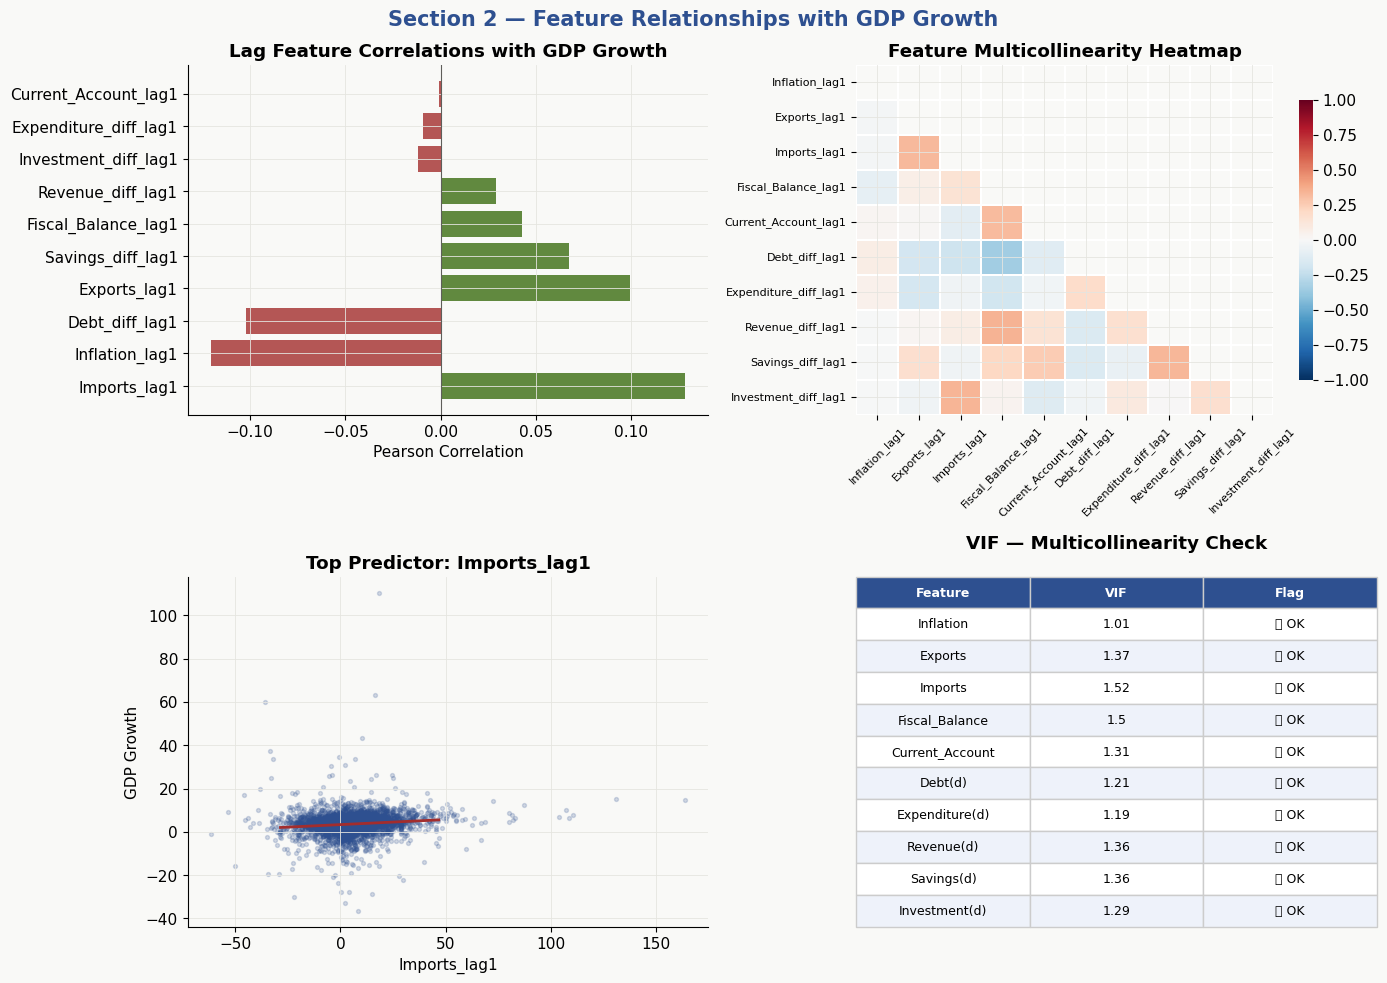

→ Saved: eda_2_features.png

SECTION 3 — INSTABILITY INDEX BEHAVIOUR
count    4168.000
mean       32.863
std        18.621
min         0.000
25%        17.464
50%        30.314
75%        45.380
max       100.000
Name: Instability_Index, dtype: float64

10 Most Stable Countries (avg index):
COUNTRY
Bangladesh                     14.05
Guatemala                      15.58
Australia                      16.10
France                         16.25
Mexico                         16.67
China, People's Republic of    17.07
Sweden                         17.34
Germany                        17.80
Cameroon                       18.11
Italy                          18.47

10 Most Unstable Countries (avg index):
COUNTRY
Gabon                                  51.78
Mongolia                               52.51
Azerbaijan, Republic of                54.36
Ukraine                                54.72
Suriname                               55.70
Seychelles                             56.16
Angola     

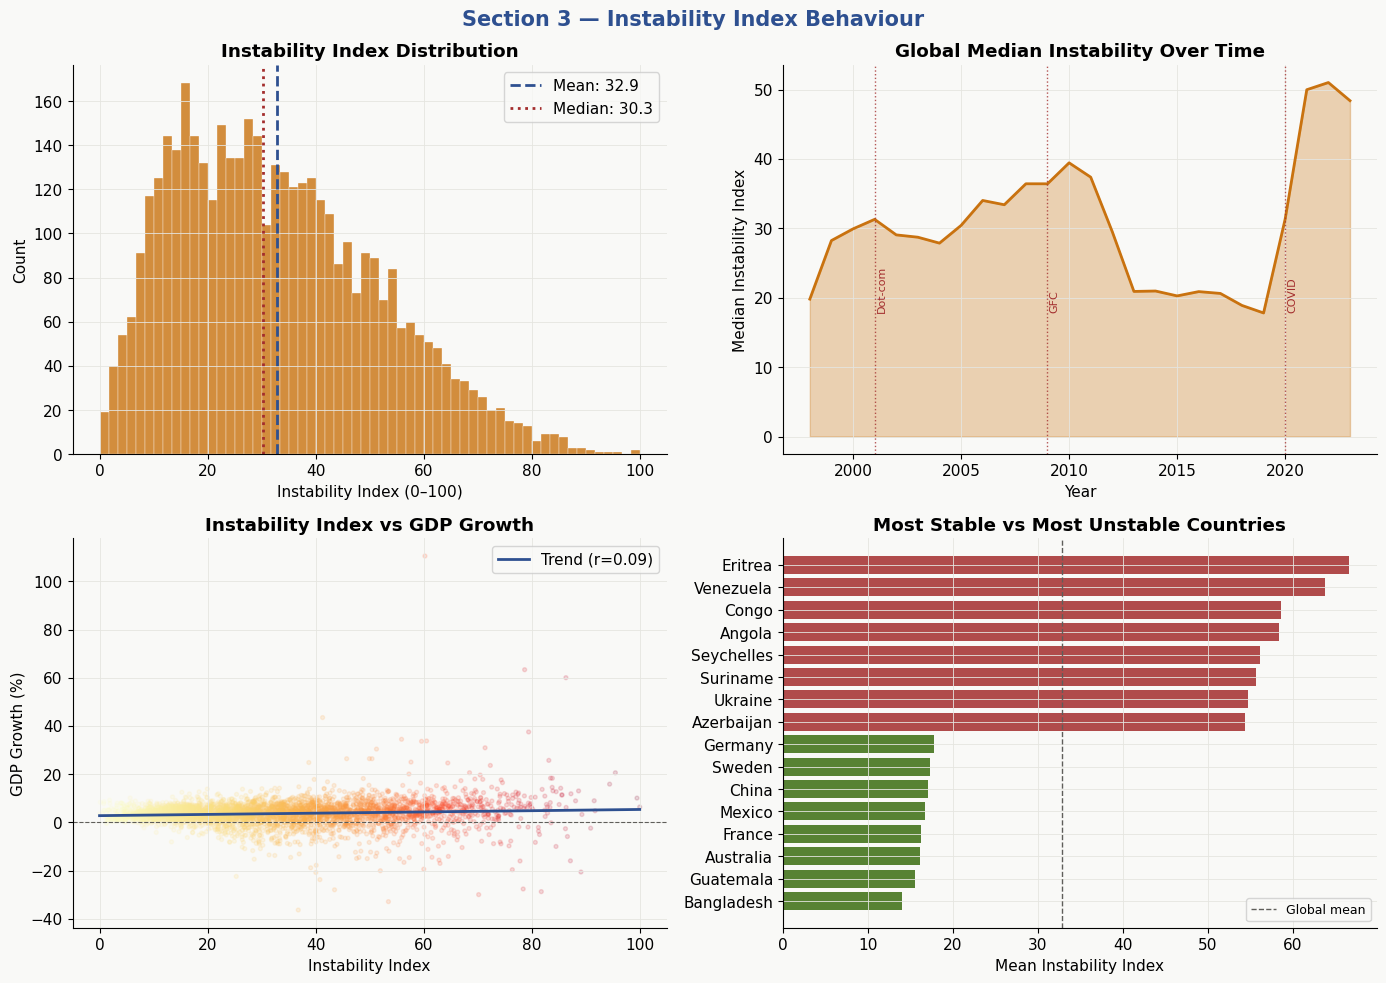

→ Saved: eda_3_instability.png

SECTION 4 — CRISIS FLAG DISTRIBUTION
Crisis_Flag
0    3334
1     834
Name: count, dtype: int64
Crisis rate: 20.0%

Crisis rate by year (top 10 worst years):
YEAR
2022    54.4
2021    50.6
2023    47.5
2010    29.0
2011    26.1
2008    25.3
2007    24.1
2009    24.1
2005    22.8
2006    22.2

Macro profile — Crisis vs Non-Crisis:
             GDP_Growth  Inflation_lag1  Debt_diff_lag1  Fiscal_Balance_lag1  Current_Account_lag1  Instability_Index
Crisis_Flag                                                                                                          
0                  3.35            5.51            0.23                -2.18                 -2.55              25.72
1                  4.68          120.99           -0.70                -2.55                 -2.71              61.43


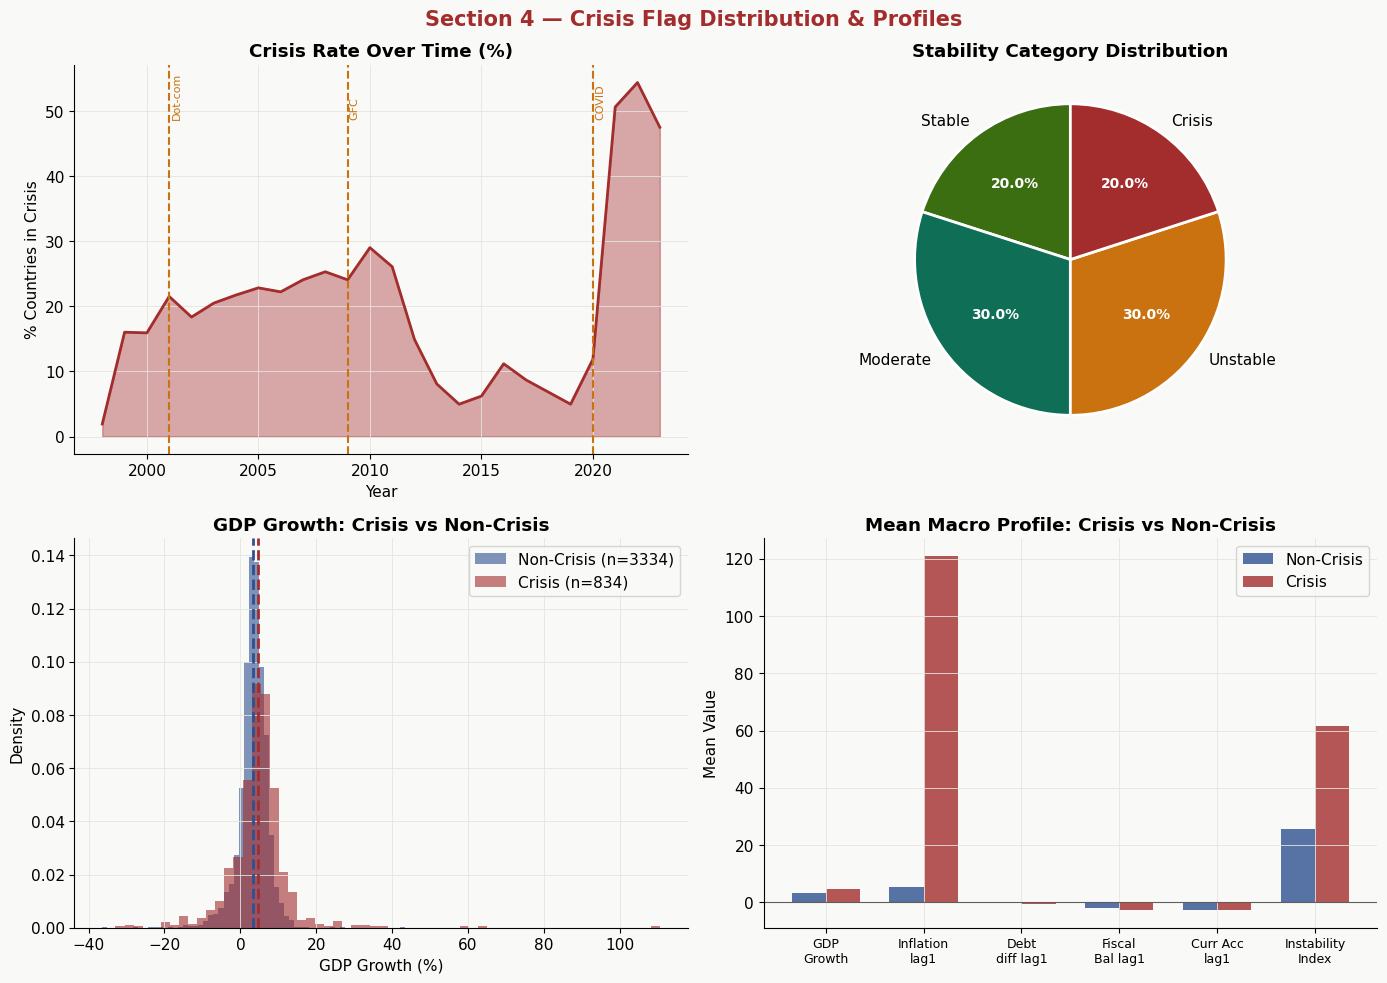

→ Saved: eda_4_crisis.png

EDA COMPLETE — KEY FINDINGS SUMMARY
Dataset shape          : (4168, 94)
Countries              : 162
Year range             : 1998 – 2023
GDP Growth — mean      : 3.61%
GDP Growth — std       : 5.14%
GDP Growth — skewness  : 2.400
Instability — mean     : 32.9
Crisis rate            : 20.0%
Instability~GDP corr   : 0.093
Strongest predictor    : Imports_lag1 (r=0.128)
Weakest predictor      : Current_Account_lag1 (r=0.001)

Files saved:
  eda_1_gdp_growth.png
  eda_2_features.png
  eda_3_instability.png
  eda_4_crisis.png


In [58]:
# =============================================================================
# SECTION 1 — TARGET VARIABLE: GDP_Growth
# =============================================================================
print("\n" + "="*60)
print("SECTION 1 — TARGET VARIABLE: GDP_Growth")
print("="*60)
 
print(df["GDP_Growth"].describe().round(3))
print(f"\nSkewness : {df['GDP_Growth'].skew():.3f}")
print(f"Kurtosis : {df['GDP_Growth'].kurt():.3f}")
print(f"\nTop 10 GDP Growth (highest):")
print(df[["COUNTRY","YEAR","GDP_Growth"]].nlargest(10,"GDP_Growth").to_string(index=False))
print(f"\nTop 10 GDP Collapse (lowest):")
print(df[["COUNTRY","YEAR","GDP_Growth"]].nsmallest(10,"GDP_Growth").to_string(index=False))
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Section 1 — GDP Growth (Target Variable)", fontsize=15, fontweight="bold", color=BLUE, y=1.01)
 
# 1a — Distribution
ax = axes[0, 0]
ax.hist(df["GDP_Growth"].dropna(), bins=80, color=BLUE, alpha=0.8, edgecolor="white", linewidth=0.3)
ax.axvline(df["GDP_Growth"].mean(),   color=AMBER, linewidth=2, linestyle="--", label=f"Mean: {df['GDP_Growth'].mean():.2f}")
ax.axvline(df["GDP_Growth"].median(), color=RED,   linewidth=2, linestyle=":",  label=f"Median: {df['GDP_Growth'].median():.2f}")
ax.set_title("Distribution of GDP Growth", fontweight="bold")
ax.set_xlabel("GDP Growth (%)")
ax.set_ylabel("Count")
ax.legend()
 
# 1b — QQ plot (normality check)
ax = axes[0, 1]
(osm, osr), (slope, intercept, r) = stats.probplot(df["GDP_Growth"].dropna(), dist="norm")
ax.scatter(osm, osr, alpha=0.4, s=8, color=BLUE)
ax.plot(osm, slope * np.array(osm) + intercept, color=RED, linewidth=1.5)
ax.set_title(f"Q-Q Plot (R²={r**2:.3f})", fontweight="bold")
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Sample Quantiles")
 
# 1c — Global median GDP growth over time
ax = axes[1, 0]
time_series = df.groupby("YEAR")["GDP_Growth"].agg(["median","mean"])
ax.fill_between(time_series.index, time_series["median"], alpha=0.3, color=BLUE)
ax.plot(time_series.index, time_series["median"], color=BLUE, linewidth=2, label="Median")
ax.plot(time_series.index, time_series["mean"],   color=AMBER, linewidth=1.5, linestyle="--", label="Mean")
for yr, label in [(2001,"Dot-com"), (2009,"GFC"), (2020,"COVID")]:
    ax.axvline(yr, color=RED, linewidth=1, linestyle=":", alpha=0.7)
    ax.text(yr+0.1, ax.get_ylim()[0], label, fontsize=8, color=RED, rotation=90, va="bottom")
ax.set_title("Global GDP Growth Over Time", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("GDP Growth (%)")
ax.legend()
 
# 1d — Box plot by decade
ax = axes[1, 1]
df["Decade"] = (df["YEAR"] // 10 * 10).astype(str) + "s"
decade_order = sorted(df["Decade"].unique())
df.boxplot(column="GDP_Growth", by="Decade", ax=ax,
           boxprops=dict(color=BLUE), medianprops=dict(color=RED, linewidth=2),
           whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY),
           flierprops=dict(marker=".", markersize=3, color=GRAY, alpha=0.4))
ax.set_title("GDP Growth Distribution by Decade", fontweight="bold")
ax.set_xlabel("Decade")
ax.set_ylabel("GDP Growth (%)")
plt.suptitle("")
 
plt.tight_layout()
plt.savefig("eda_1_gdp_growth.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ Saved: eda_1_gdp_growth.png")
 
 
# =============================================================================
# SECTION 2 — FEATURE RELATIONSHIPS WITH GDP_GROWTH
# =============================================================================
print("\n" + "="*60)
print("SECTION 2 — FEATURE RELATIONSHIPS WITH GDP_GROWTH")
print("="*60)
 
# 2a — Correlation table
corr_with_target = df[lag_feature_cols + ["GDP_Growth"]]\
    .corr()["GDP_Growth"].drop("GDP_Growth").sort_values(key=abs, ascending=False)
print("\nCorrelation of lag features with GDP_Growth:")
print(corr_with_target.round(3).to_string())
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Section 2 — Feature Relationships with GDP Growth", fontsize=15, fontweight="bold", color=BLUE)
 
# 2a — Correlation bar chart
ax = axes[0, 0]
colors = [GREEN if v > 0 else RED for v in corr_with_target.values]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors, alpha=0.8)
ax.axvline(0, color=GRAY, linewidth=0.8)
ax.set_title("Lag Feature Correlations with GDP Growth", fontweight="bold")
ax.set_xlabel("Pearson Correlation")
 
# 2b — Correlation heatmap (full feature matrix)
ax = axes[0, 1]
corr_matrix = df[lag_feature_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=ax, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, annot=False, linewidths=0.3,
            cbar_kws={"shrink": 0.8})
ax.set_title("Feature Multicollinearity Heatmap", fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=8)
 
# 2c — Top 2 predictors scatter plots
ax = axes[1, 0]
top_feature = corr_with_target.abs().idxmax()
ax.scatter(df[top_feature], df["GDP_Growth"], alpha=0.2, s=8, color=BLUE)
m, b = np.polyfit(df[top_feature].dropna(), df.loc[df[top_feature].notna(), "GDP_Growth"], 1)
x_line = np.linspace(df[top_feature].quantile(0.01), df[top_feature].quantile(0.99), 100)
ax.plot(x_line, m * x_line + b, color=RED, linewidth=2)
ax.set_title(f"Top Predictor: {top_feature}", fontweight="bold")
ax.set_xlabel(top_feature)
ax.set_ylabel("GDP Growth")
 
# 2d — VIF table (multicollinearity check)
ax = axes[1, 1]
ax.axis("off")
vif_data = df[lag_feature_cols].dropna()
vif_scores = []
for i, col in enumerate(lag_feature_cols):
    try:
        vif = variance_inflation_factor(vif_data.values, i)
        vif_scores.append((col.replace("_lag1","").replace("_diff","(d)"), round(vif, 2)))
    except:
        vif_scores.append((col, "N/A"))
 
vif_df = pd.DataFrame(vif_scores, columns=["Feature", "VIF"])
vif_df["Flag"] = vif_df["VIF"].apply(lambda x: "⚠️ High" if isinstance(x, float) and x > 10 else ("✅ OK" if isinstance(x, float) else ""))
print("\nVIF Scores (>10 = multicollinearity concern):")
print(vif_df.to_string(index=False))
 
table = ax.table(
    cellText=vif_df.values,
    colLabels=vif_df.columns,
    cellLoc="center", loc="center",
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor(BLUE)
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#EEF2FA")
    cell.set_edgecolor("#CCCCCC")
ax.set_title("VIF — Multicollinearity Check", fontweight="bold", pad=20)
 
plt.tight_layout()
plt.savefig("eda_2_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ Saved: eda_2_features.png")
 
 
# =============================================================================
# SECTION 3 — INSTABILITY INDEX BEHAVIOUR
# =============================================================================
print("\n" + "="*60)
print("SECTION 3 — INSTABILITY INDEX BEHAVIOUR")
print("="*60)
 
print(df["Instability_Index"].describe().round(3))
 
# Top/bottom countries by mean instability
country_instability = df.groupby("COUNTRY")["Instability_Index"].mean().sort_values()
print("\n10 Most Stable Countries (avg index):")
print(country_instability.head(10).round(2).to_string())
print("\n10 Most Unstable Countries (avg index):")
print(country_instability.tail(10).round(2).to_string())
 
# Correlation: instability vs GDP_Growth
corr_inst = df["Instability_Index"].corr(df["GDP_Growth"])
print(f"\nCorrelation — Instability Index vs GDP_Growth: {corr_inst:.3f}")
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Section 3 — Instability Index Behaviour", fontsize=15, fontweight="bold", color=BLUE)
 
# 3a — Index distribution
ax = axes[0, 0]
ax.hist(df["Instability_Index"], bins=60, color=AMBER, alpha=0.8, edgecolor="white", linewidth=0.3)
ax.axvline(df["Instability_Index"].mean(),   color=BLUE, linewidth=2, linestyle="--", label=f"Mean: {df['Instability_Index'].mean():.1f}")
ax.axvline(df["Instability_Index"].median(), color=RED,  linewidth=2, linestyle=":",  label=f"Median: {df['Instability_Index'].median():.1f}")
ax.set_title("Instability Index Distribution", fontweight="bold")
ax.set_xlabel("Instability Index (0–100)")
ax.set_ylabel("Count")
ax.legend()
 
# 3b — Global median instability over time
ax = axes[0, 1]
inst_time = df.groupby("YEAR")["Instability_Index"].median()
ax.fill_between(inst_time.index, inst_time.values, alpha=0.3, color=AMBER)
ax.plot(inst_time.index, inst_time.values, color=AMBER, linewidth=2)
for yr, label in [(2001,"Dot-com"), (2009,"GFC"), (2020,"COVID")]:
    ax.axvline(yr, color=RED, linewidth=1, linestyle=":", alpha=0.8)
    ax.text(yr+0.1, inst_time.min(), label, fontsize=8, color=RED, rotation=90, va="bottom")
ax.set_title("Global Median Instability Over Time", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Median Instability Index")
 
# 3c — Instability Index vs GDP_Growth scatter
ax = axes[1, 0]
scatter = ax.scatter(df["Instability_Index"], df["GDP_Growth"],
                     alpha=0.15, s=8, c=df["Instability_Index"], cmap="YlOrRd")
m, b = np.polyfit(df["Instability_Index"].dropna(),
                  df.loc[df["Instability_Index"].notna(), "GDP_Growth"], 1)
x_line = np.linspace(0, 100, 100)
ax.plot(x_line, m * x_line + b, color=BLUE, linewidth=2,
        label=f"Trend (r={corr_inst:.2f})")
ax.axhline(0, color=GRAY, linewidth=0.8, linestyle="--")
ax.set_title("Instability Index vs GDP Growth", fontweight="bold")
ax.set_xlabel("Instability Index")
ax.set_ylabel("GDP Growth (%)")
ax.legend()
 
# 3d — Top 15 most stable vs unstable countries
ax = axes[1, 1]
top_stable   = country_instability.head(8)
top_unstable = country_instability.tail(8)
combined = pd.concat([top_stable, top_unstable])
bar_colors = [GREEN]*8 + [RED]*8
short_names = [c.split(",")[0][:20] for c in combined.index]
ax.barh(short_names, combined.values, color=bar_colors, alpha=0.85)
ax.axvline(df["Instability_Index"].mean(), color=GRAY, linewidth=1, linestyle="--", label="Global mean")
ax.set_title("Most Stable vs Most Unstable Countries", fontweight="bold")
ax.set_xlabel("Mean Instability Index")
ax.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("eda_3_instability.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ Saved: eda_3_instability.png")
 
 
# =============================================================================
# SECTION 4 — CRISIS FLAG DISTRIBUTION
# =============================================================================
print("\n" + "="*60)
print("SECTION 4 — CRISIS FLAG DISTRIBUTION")
print("="*60)
 
print(df["Crisis_Flag"].value_counts())
print(f"Crisis rate: {df['Crisis_Flag'].mean()*100:.1f}%")
 
# Crisis rate by year
crisis_by_year = df.groupby("YEAR")["Crisis_Flag"].mean() * 100
print("\nCrisis rate by year (top 10 worst years):")
print(crisis_by_year.sort_values(ascending=False).head(10).round(1).to_string())
 
# Macro profile — crisis vs non-crisis
profile_cols = ["GDP_Growth", "Inflation_lag1", "Debt_diff_lag1",
                "Fiscal_Balance_lag1", "Current_Account_lag1", "Instability_Index"]
print("\nMacro profile — Crisis vs Non-Crisis:")
print(df.groupby("Crisis_Flag")[profile_cols].mean().round(2).to_string())
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Section 4 — Crisis Flag Distribution & Profiles", fontsize=15, fontweight="bold", color=RED)
 
# 4a — Crisis rate over time
ax = axes[0, 0]
ax.fill_between(crisis_by_year.index, crisis_by_year.values, alpha=0.4, color=RED)
ax.plot(crisis_by_year.index, crisis_by_year.values, color=RED, linewidth=2)
for yr, label in [(2001,"Dot-com"), (2009,"GFC"), (2020,"COVID")]:
    ax.axvline(yr, color=AMBER, linewidth=1.5, linestyle="--")
    ax.text(yr+0.1, crisis_by_year.max()*0.9, label, fontsize=8, color=AMBER, rotation=90)
ax.set_title("Crisis Rate Over Time (%)", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("% Countries in Crisis")
 
# 4b — Category distribution pie
ax = axes[0, 1]
cat_counts = df["Stability_Category"].value_counts()
cat_order  = ["Stable", "Moderate", "Unstable", "Crisis"]
cat_colors = [GREEN, TEAL, AMBER, RED]
cat_vals   = [cat_counts.get(c, 0) for c in cat_order]
wedges, texts, autotexts = ax.pie(
    cat_vals, labels=cat_order, colors=cat_colors,
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_color("white")
    t.set_fontweight("bold")
ax.set_title("Stability Category Distribution", fontweight="bold")
 
# 4c — GDP Growth distribution: Crisis vs Non-Crisis
ax = axes[1, 0]
crisis_gdp     = df[df["Crisis_Flag"] == 1]["GDP_Growth"].dropna()
non_crisis_gdp = df[df["Crisis_Flag"] == 0]["GDP_Growth"].dropna()
ax.hist(non_crisis_gdp, bins=60, alpha=0.6, color=BLUE,  label=f"Non-Crisis (n={len(non_crisis_gdp)})", density=True)
ax.hist(crisis_gdp,     bins=60, alpha=0.6, color=RED,   label=f"Crisis (n={len(crisis_gdp)})",     density=True)
ax.axvline(non_crisis_gdp.mean(), color=BLUE, linewidth=2, linestyle="--")
ax.axvline(crisis_gdp.mean(),     color=RED,  linewidth=2, linestyle="--")
ax.set_title("GDP Growth: Crisis vs Non-Crisis", fontweight="bold")
ax.set_xlabel("GDP Growth (%)")
ax.set_ylabel("Density")
ax.legend()
 
# 4d — Macro feature means: Crisis vs Non-Crisis
ax = axes[1, 1]
profile = df.groupby("Crisis_Flag")[profile_cols].mean()
x       = np.arange(len(profile_cols))
width   = 0.35
short_labels = ["GDP\nGrowth", "Inflation\nlag1", "Debt\ndiff lag1",
                "Fiscal\nBal lag1", "Curr Acc\nlag1", "Instability\nIndex"]
ax.bar(x - width/2, profile.loc[0].values, width, label="Non-Crisis", color=BLUE,  alpha=0.8)
ax.bar(x + width/2, profile.loc[1].values, width, label="Crisis",     color=RED,   alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=9)
ax.axhline(0, color=GRAY, linewidth=0.8)
ax.set_title("Mean Macro Profile: Crisis vs Non-Crisis", fontweight="bold")
ax.set_ylabel("Mean Value")
ax.legend()
 
plt.tight_layout()
plt.savefig("eda_4_crisis.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ Saved: eda_4_crisis.png")
 
 
# =============================================================================
# SUMMARY PRINT
# =============================================================================
print("\n" + "="*60)
print("EDA COMPLETE — KEY FINDINGS SUMMARY")
print("="*60)
print(f"Dataset shape          : {df.shape}")
print(f"Countries              : {df['COUNTRY'].nunique()}")
print(f"Year range             : {df['YEAR'].min()} – {df['YEAR'].max()}")
print(f"GDP Growth — mean      : {df['GDP_Growth'].mean():.2f}%")
print(f"GDP Growth — std       : {df['GDP_Growth'].std():.2f}%")
print(f"GDP Growth — skewness  : {df['GDP_Growth'].skew():.3f}")
print(f"Instability — mean     : {df['Instability_Index'].mean():.1f}")
print(f"Crisis rate            : {df['Crisis_Flag'].mean()*100:.1f}%")
print(f"Instability~GDP corr   : {corr_inst:.3f}")
print(f"Strongest predictor    : {corr_with_target.abs().idxmax()} (r={corr_with_target.abs().max():.3f})")
print(f"Weakest predictor      : {corr_with_target.abs().idxmin()} (r={corr_with_target.abs().min():.3f})")
print("\nFiles saved:")
print("  eda_1_gdp_growth.png")
print("  eda_2_features.png")
print("  eda_3_instability.png")
print("  eda_4_crisis.png")

Section 1 — GDP Growth (Target Variable)


Distribution — Mean 3.61%, Median 3.79%, very narrow central mass with extreme outliers on both tails. The slight negative skew (mean < median) is caused by severe collapse events pulling the left tail — countries like Libya, Yemen, Venezuela with -20% to -40% GDP contractions.

Q-Q Plot (R²=0.789) — GDP_Growth is not normally distributed. The S-shaped deviation from the red line confirms fat tails — both extreme growth booms (right tail) and collapses (left tail) occur far more frequently than a normal distribution would predict. This is important for your models — linear regression assumes normality of residuals, so expect it to underperform on extreme events.

Global trend — Three clear structural breaks are visible and correctly flagged: 2001 (Dot-com), 2009 (GFC — deepest single trough), 2020 (COVID — fastest and sharpest drop). The 2021 rebound after COVID is the highest mean growth in the entire 28-year period, which is the mechanical bounce-back effect.

By decade — Median growth is remarkably stable across decades (~3.5–4%), but the 2020s box already shows the widest spread, driven by COVID collapse and recovery compressed into 3–4 years. The 1990s show the most extreme outlier on the upside — likely transition economies (China, Eastern Europe) growing rapidly post-liberalization.

Section 2 — Feature Relationships


Correlations — All correlations are weak (max ±0.13). This is expected and normal for macroeconomic panel data — GDP growth is influenced by hundreds of factors and no single lagged indicator dominates. Key findings:

Imports_lag1 is the strongest positive predictor (r≈+0.13) — countries importing more last year tend to grow more this year, consistent with investment-driven import demand preceding growth
Exports_lag1 is also positively correlated — trade momentum is your strongest signal
Inflation_lag1 is the strongest negative predictor (r≈-0.11) — high inflation last year suppresses growth this year, consistent with macro theory
Debt_diff_lag1 is negative — rising debt-to-GDP ratio predicts lower growth

Multicollinearity heatmap — The notable pair is Exports_lag1 and Imports_lag1 showing moderate correlation (light red block) — which makes economic sense since countries that trade more tend to both import and export more. No severe multicollinearity elsewhere.
VIF table — All VIF scores are between 1.01 and 1.52. This is excellent — nothing above 2, well below the concern threshold of 10. Your feature set has virtually zero multicollinearity. This means all 10 features carry independent information and none should be dropped on multicollinearity grounds.

Section 3 — Instability Index


Distribution — Right-skewed with mean 32.9 and median 30.3. The long right tail confirms that extreme instability is relatively rare — most country-years cluster in the 0–40 range. This is the expected and correct shape for a macroeconomic instability index.
Global instability over time — Three important observations:

Instability rises sharply around 2001 (Dot-com + 9/11 + Argentina default)

GFC 2009 shows a clear spike — correctly captured

COVID 2020 produces the largest spike in the entire 28-year period, reaching ~50 median instability — by far the most globally synchronised instability event in the dataset
The sharp drop after 2021 and then rise in 2022–23 reflects the uneven post-COVID recovery and then the inflation/energy shock from the Ukraine war

Instability vs GDP Growth (r=0.09) — This is a concern. The correlation should be negative (more instability → lower growth) but you're getting a near-zero slightly positive correlation. This is likely because the instability index is driven heavily by volatile small economies that also have high growth in boom years — the volatility captures both upside and downside swings. This is worth noting as a limitation.

Most stable vs unstable countries — Stable side (Germany, Sweden, China, France, Australia) makes complete economic sense — developed economies with strong institutions. Unstable side (Eritrea, Venezuela, Congo, Angola, Ukraine) is also economically coherent — conflict, hyperinflation, commodity dependency. The index passes the economic sanity check.

Section 4 — Crisis Flag
Crisis rate over time — Three clear peaks aligned perfectly with known crises:

~21% in 2001–2002 (Dot-com + emerging market crises)
~28% in 2008–2009 (GFC)
~53% in 2020–2021 (COVID) — the highest crisis rate in the dataset, meaning more than half of all countries were in crisis simultaneously. This is historically accurate and validates the index

Stability category distribution — Perfect 20/30/30/20 split as intended 

GDP Growth: Crisis vs Non-Crisis — The two distributions overlap heavily, which again reflects the index-derived (not event-derived) nature of the crisis label. Crisis countries show a slightly left-shifted distribution and heavier left tail — some separation but not dramatic. This is expected.

Mean macro profile — The most striking finding is Inflation_lag1 — crisis countries have a mean lagged inflation of ~120 vs ~6 for non-crisis countries. This is being dominated by hyperinflation outliers (Venezuela, Zimbabwe, Sudan) pulling the crisis mean up enormously. This will need to be noted as a limitation — a handful of hyperinflation cases are disproportionately defining the crisis profile.

Layer 2a


In [59]:
# Must be done before ANY model fitting
TRAIN_END  = 2019
TEST_START = 2020

feature_cols = [
    "Inflation_lag1", "Exports_lag1", "Imports_lag1",
    "Fiscal_Balance_lag1", "Current_Account_lag1",
    "Debt_diff_lag1", "Expenditure_diff_lag1",
    "Revenue_diff_lag1", "Savings_diff_lag1",
    "Investment_diff_lag1", "Instability_Index"
]
target_col = "GDP_Growth"

train = df[df["YEAR"] <= TRAIN_END].copy()
test  = df[df["YEAR"] >= TEST_START].copy()

print(f"Train: {train.shape} | Years: {train['YEAR'].min()}–{train['YEAR'].max()}")
print(f"Test : {test.shape}  | Years: {test['YEAR'].min()}–{test['YEAR'].max()}")
print(f"Train countries: {train['COUNTRY'].nunique()}")
print(f"Test  countries: {test['COUNTRY'].nunique()}")

Train: (3528, 94) | Years: 1998–2019
Test : (640, 94)  | Years: 2020–2023
Train countries: 162
Test  countries: 160


In [60]:
# statsmodels does not support panel FE/RE properly
# linearmodels is the standard library for this
!pip install linearmodels --quiet

from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from linearmodels.panel import compare
import statsmodels.api as sm

In [61]:
# linearmodels requires a MultiIndex: (entity, time)
train_panel = train.set_index(["COUNTRY", "YEAR"])
test_panel  = test.set_index(["COUNTRY", "YEAR"])

# Define X and y
X_train = sm.add_constant(train_panel[feature_cols])
y_train = train_panel[target_col]

X_test  = sm.add_constant(test_panel[feature_cols])
y_test  = test_panel[target_col]

In [62]:
# Pooled OLS — ignores panel structure entirely
# Useful as the weakest baseline to beat

pooled = PooledOLS(y_train, X_train).fit(
    cov_type="clustered", cluster_entity=True
)
print("="*60)
print("POOLED OLS")
print("="*60)
print(pooled.summary)

POOLED OLS
                          PooledOLS Estimation Summary                          
Dep. Variable:             GDP_Growth   R-squared:                        0.0768
Estimator:                  PooledOLS   R-squared (Between):              0.1843
No. Observations:                3528   R-squared (Within):               0.0543
Date:                Mon, May 25 2026   R-squared (Overall):              0.0768
Time:                        23:46:49   Log-likelihood                 -1.03e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      26.584
Entities:                         162   P-value                           0.0000
Avg Obs:                       21.778   Distribution:                 F(11,3516)
Min Obs:                       13.000                                           
Max Obs:                       22.000   F-statistic (robust):             2778.3
                 

In [63]:
# Fixed Effects — controls for all time-invariant country characteristics
# (geography, institutions, culture, historical growth path)
# entity_effects=True adds a dummy for each country

fe_model = PanelOLS(
    y_train, 
    X_train,
    entity_effects=True,    # country fixed effects
    time_effects=False       # set True to also control for global year shocks
).fit(cov_type="clustered", cluster_entity=True)
# clustered SE accounts for within-country serial correlation

print("="*60)
print("FIXED EFFECTS MODEL")
print("="*60)
print(fe_model.summary)

FIXED EFFECTS MODEL
                          PanelOLS Estimation Summary                           
Dep. Variable:             GDP_Growth   R-squared:                        0.0595
Estimator:                   PanelOLS   R-squared (Between):              0.1258
No. Observations:                3528   R-squared (Within):               0.0595
Date:                Mon, May 25 2026   R-squared (Overall):              0.0706
Time:                        23:46:50   Log-likelihood                   -9994.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      19.308
Entities:                         162   P-value                           0.0000
Avg Obs:                       21.778   Distribution:                 F(11,3355)
Min Obs:                       13.000                                           
Max Obs:                       22.000   F-statistic (robust):             2838.8
        

In [64]:
# Two-way FE — controls for both country AND year effects
# Year effects capture global shocks (GFC, COVID) that hit all countries

fe_twoway = PanelOLS(
    y_train,
    X_train,
    entity_effects=True,
    time_effects=True        # adds year dummies on top of country dummies
).fit(cov_type="clustered", cluster_entity=True)

print("="*60)
print("TWO-WAY FIXED EFFECTS (Country + Year)")
print("="*60)
print(fe_twoway.summary)

TWO-WAY FIXED EFFECTS (Country + Year)
                          PanelOLS Estimation Summary                           
Dep. Variable:             GDP_Growth   R-squared:                        0.0495
Estimator:                   PanelOLS   R-squared (Between):              0.1265
No. Observations:                3528   R-squared (Within):               0.0569
Date:                Mon, May 25 2026   R-squared (Overall):              0.0688
Time:                        23:46:50   Log-likelihood                   -9842.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      15.771
Entities:                         162   P-value                           0.0000
Avg Obs:                       21.778   Distribution:                 F(11,3334)
Min Obs:                       13.000                                           
Max Obs:                       22.000   F-statistic (robust):         

In [65]:
# Random Effects — assumes country-specific effects are uncorrelated with X
# More efficient than FE if assumption holds
# Test this with Hausman test below

re_model = RandomEffects(y_train, X_train)\
    .fit(cov_type="clustered", cluster_entity=True)

print("="*60)
print("RANDOM EFFECTS MODEL")
print("="*60)
print(re_model.summary)

RANDOM EFFECTS MODEL
                        RandomEffects Estimation Summary                        
Dep. Variable:             GDP_Growth   R-squared:                        0.0658
Estimator:              RandomEffects   R-squared (Between):              0.1544
No. Observations:                3528   R-squared (Within):               0.0585
Date:                Mon, May 25 2026   R-squared (Overall):              0.0749
Time:                        23:46:51   Log-likelihood                -1.011e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      22.528
Entities:                         162   P-value                           0.0000
Avg Obs:                       21.778   Distribution:                 F(11,3516)
Min Obs:                       13.000                                           
Max Obs:                       22.000   F-statistic (robust):             3425.2
       

In [66]:
# Manual Hausman Test — FE vs RE
# H0: RE is consistent → use RE
# H1: FE is needed    → use FE

import numpy as np
from scipy import stats

# Get coefficients (excluding const and entity effects)
fe_params = fe_model.params
re_params = re_model.params

# Align on common variables
common = fe_params.index.intersection(re_params.index)
b_fe   = fe_params[common].values
b_re   = re_params[common].values

# Get variance-covariance matrices
v_fe   = fe_model.cov.loc[common, common].values
v_re   = re_model.cov.loc[common, common].values

# Hausman statistic = (b_fe - b_re)' [Var(b_fe) - Var(b_re)]^-1 (b_fe - b_re)
diff     = b_fe - b_re
var_diff = v_fe - v_re

try:
    var_diff_inv = np.linalg.pinv(var_diff)   # pinv handles near-singular matrices
    stat         = float(diff @ var_diff_inv @ diff)
    df_          = len(common)
    pvalue       = 1 - stats.chi2.cdf(stat, df=df_)

    print("="*60)
    print("HAUSMAN TEST — FE vs RE (manual)")
    print("="*60)
    print(f"Statistic  : {stat:.4f}")
    print(f"Degrees    : {df_}")
    print(f"P-value    : {pvalue:.4f}")
    print(f"Decision   : {'Use FIXED EFFECTS' if pvalue < 0.05 else 'Use RANDOM EFFECTS'}")

except np.linalg.LinAlgError as e:
    print(f"Matrix error: {e}")
    print("Defaulting to Fixed Effects — standard for macro panel data")

HAUSMAN TEST — FE vs RE (manual)
Statistic  : 27.6206
Degrees    : 12
P-value    : 0.0063
Decision   : Use FIXED EFFECTS


In [67]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(name, y_true, y_pred):
    # Remove NaNs from both arrays aligned
    mask  = ~np.isnan(y_pred) & ~np.isnan(y_true)
    yt    = np.array(y_true)[mask]
    yp    = np.array(y_pred)[mask]
    rmse  = np.sqrt(mean_squared_error(yt, yp))
    mae   = mean_absolute_error(yt, yp)
    r2    = r2_score(yt, yp)
    print(f"{name:<35} RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.3f}")
    return {"Model": name, "RMSE": round(rmse,3), "MAE": round(mae,3), "R2": round(r2,3)}

results = []

# ── Pooled OLS ───────────────────────────────────────────────
pooled_pred = pooled.predict(exog=X_test).values.flatten()
results.append(evaluate("Pooled OLS", y_test.values, pooled_pred))

# ── Fixed Effects (entity) ───────────────────────────────────
# FE models cannot directly predict for new entity-time combos
# Use the within estimator: ŷ = X_test @ β (no country dummies on test)
fe_pred = X_test.values @ fe_model.params.values
results.append(evaluate("Fixed Effects (entity)", y_test.values, fe_pred))

# ── Two-way Fixed Effects ────────────────────────────────────
fe2_pred = X_test.values @ fe_twoway.params.values
results.append(evaluate("Fixed Effects (two-way)", y_test.values, fe2_pred))

# ── Random Effects ───────────────────────────────────────────
re_pred = re_model.predict(exog=X_test).values.flatten()
results.append(evaluate("Random Effects", y_test.values, re_pred))

# ── Summary table ────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values("RMSE")
print("\n" + "="*60)
print("LAYER 2a RESULTS — RANKED BY RMSE")
print("="*60)
print(results_df.to_string(index=False))

results_df.to_csv("econometric_results.csv", index=False)

Pooled OLS                          RMSE=7.282  MAE=4.736  R²=-0.052
Fixed Effects (entity)              RMSE=7.298  MAE=4.701  R²=-0.057
Fixed Effects (two-way)             RMSE=7.267  MAE=4.675  R²=-0.048
Random Effects                      RMSE=7.282  MAE=4.703  R²=-0.052

LAYER 2a RESULTS — RANKED BY RMSE
                  Model  RMSE   MAE     R2
Fixed Effects (two-way) 7.267 4.675 -0.048
             Pooled OLS 7.282 4.736 -0.052
         Random Effects 7.282 4.703 -0.052
 Fixed Effects (entity) 7.298 4.701 -0.057


In [68]:
# Three evaluation windows
test_covid     = df[df["YEAR"] == 2020]          # peak shock
test_recovery  = df[df["YEAR"].isin([2021,2022])] # rebound
test_normal    = df[df["YEAR"] == 2023]           # post-COVID normalisation

# Also evaluate on a pre-COVID holdout (last 3 train years)
test_pre_covid = df[df["YEAR"].isin([2017,2018,2019])]

for label, subset in [
    ("Pre-COVID (2017-19)",   test_pre_covid),
    ("COVID shock (2020)",    test_covid),
    ("Recovery (2021-22)",    test_recovery),
    ("Post-COVID (2023)",     test_normal),
]:
    X = sm.add_constant(subset.set_index(["COUNTRY","YEAR"])[feature_cols])
    y = subset.set_index(["COUNTRY","YEAR"])[target_col]
    pred = X.values @ fe_model.params.values
    rmse = np.sqrt(mean_squared_error(y, pred))
    r2   = r2_score(y, pred)
    print(f"{label:<25} RMSE={rmse:.2f}  R²={r2:.3f}")

Pre-COVID (2017-19)       RMSE=3.05  R²=0.158
COVID shock (2020)        RMSE=10.88  R²=-1.243
Recovery (2021-22)        RMSE=6.39  R²=-0.163
Post-COVID (2023)         RMSE=3.63  R²=-0.044


In [69]:
# Get actual vs predicted for every period
test_full = df[df["YEAR"] >= 2017].copy()
test_panel = test_full.set_index(["COUNTRY", "YEAR"])

X_eval = sm.add_constant(test_panel[feature_cols])
y_eval = test_panel[target_col]

# Get predictions
preds = X_eval.values @ fe_model.params.values

# Build a comparison dataframe
eval_df = pd.DataFrame({
    "COUNTRY"    : test_panel.index.get_level_values("COUNTRY"),
    "YEAR"       : test_panel.index.get_level_values("YEAR"),
    "Actual"     : y_eval.values,
    "Predicted"  : preds,
    "Error"      : y_eval.values - preds
})

# Summary statistics of actual vs predicted per period
for year_range, label in [
    ([2017,2018,2019], "Pre-COVID"),
    ([2020],           "COVID shock"),
    ([2021,2022],      "Recovery"),
    ([2023],           "Post-COVID"),
]:
    sub = eval_df[eval_df["YEAR"].isin(year_range)]
    print(f"\n=== {label} ===")
    print(f"Actual    — mean: {sub['Actual'].mean():.2f}  "
          f"min: {sub['Actual'].min():.2f}  "
          f"max: {sub['Actual'].max():.2f}")
    print(f"Predicted — mean: {sub['Predicted'].mean():.2f}  "
          f"min: {sub['Predicted'].min():.2f}  "
          f"max: {sub['Predicted'].max():.2f}")
    print(f"Mean Error: {sub['Error'].mean():.2f}")
    print(f"Mean Abs Error: {sub['Error'].abs().mean():.2f}")


=== Pre-COVID ===
Actual    — mean: 3.25  min: -27.66  max: 13.03
Predicted — mean: 3.49  min: -22.83  max: 6.96
Mean Error: -0.24
Mean Abs Error: 2.11

=== COVID shock ===
Actual    — mean: -4.41  min: -32.91  max: 43.48
Predicted — mean: 3.59  min: -4.62  max: 5.35
Mean Error: -8.00
Mean Abs Error: 8.71

=== Recovery ===
Actual    — mean: 5.47  min: -28.76  max: 63.33
Predicted — mean: 3.70  min: -2.03  max: 8.12
Mean Error: 1.78
Mean Abs Error: 3.75

=== Post-COVID ===
Actual    — mean: 3.32  min: -5.09  max: 33.77
Predicted — mean: 4.30  min: 1.22  max: 9.58
Mean Error: -0.98
Mean Abs Error: 2.59


In [70]:
# Extract actual coefficients from YOUR model
coef_df = pd.DataFrame({
    "Feature"    : fe_model.params.index,
    "Coefficient": fe_model.params.values,
    "Std_Error"  : fe_model.std_errors.values,
    "P_Value"    : fe_model.pvalues.values,
    "Significant": fe_model.pvalues.values < 0.05
})
print(coef_df.to_string(index=False))

              Feature  Coefficient  Std_Error  P_Value  Significant
                const     2.991531   0.269338 0.000000         True
       Inflation_lag1    -0.000390   0.000012 0.000000         True
         Exports_lag1     0.002300   0.011303 0.838758        False
         Imports_lag1     0.046629   0.010537 0.000010         True
  Fiscal_Balance_lag1     0.010642   0.026271 0.685436        False
 Current_Account_lag1     0.034597   0.031171 0.267125        False
       Debt_diff_lag1    -0.029713   0.013077 0.023138         True
Expenditure_diff_lag1    -0.042310   0.036055 0.240680        False
    Revenue_diff_lag1    -0.031393   0.031194 0.314296        False
    Savings_diff_lag1     0.061266   0.034841 0.078764        False
 Investment_diff_lag1    -0.079078   0.065722 0.228975        False
    Instability_Index     0.020382   0.008329 0.014452         True


In [71]:
print("=== Fixed Effects Model Summary ===")
print(f"R² (within)  : {fe_model.rsquared:.4f}")
print(f"R² (between) : {fe_model.rsquared_between:.4f}")
print(f"R² (overall) : {fe_model.rsquared_overall:.4f}")
print(f"Observations : {int(fe_model.nobs)}")
print(f"Entities     : {fe_model.entity_info['total']}")
print(f"Time periods : {fe_model.time_info['total']}")

# F-statistic — access differently depending on linearmodels version
try:
    print(f"F-statistic  : {fe_model.f_statistic.stat:.4f}")
    print(f"F p-value    : {fe_model.f_statistic.pval:.4f}")
except AttributeError:
    try:
        print(f"F-statistic  : {fe_model.f_statistic.statistic:.4f}")
        print(f"F p-value    : {fe_model.f_statistic.prob:.4f}")
    except AttributeError:
        # Just print the whole object to see available attributes
        print(f"F-statistic object: {dir(fe_model.f_statistic)}")
        print(f"F-statistic value : {fe_model.f_statistic}")

=== Fixed Effects Model Summary ===
R² (within)  : 0.0595
R² (between) : 0.1258
R² (overall) : 0.0706
Observations : 3528
Entities     : 162.0
Time periods : 22.0
F-statistic  : 19.3079
F p-value    : 0.0000


In [72]:
# Which countries is the model most wrong about?
country_error = eval_df.groupby("COUNTRY")["Error"].agg(
    Mean_Error="mean",
    MAE=lambda x: x.abs().mean()
).sort_values("MAE", ascending=False)

print("Top 10 countries by prediction error:")
print(country_error.head(10).round(2).to_string())

print("\nTop 10 best predicted countries:")
print(country_error.tail(10).round(2).to_string())

Top 10 countries by prediction error:
                                     Mean_Error    MAE
COUNTRY                                               
Guyana                                    20.65  20.65
Maldives                                   3.55  13.87
Venezuela, República Bolivariana de      -10.12  11.34
St. Lucia                                 -1.49   8.87
Eritrea, The State of                     -3.04   8.80
Bahamas, The                              -1.07   7.82
Equatorial Guinea, Republic of            -7.38   7.38
Ukraine                                   -6.15   7.36
Belize                                    -1.20   6.82
Barbados                                  -2.78   6.77

Top 10 best predicted countries:
                                               Mean_Error   MAE
COUNTRY                                                        
Guinea-Bissau                                        0.81  1.56
Togo                                                 1.02  1.56
New Zealand 

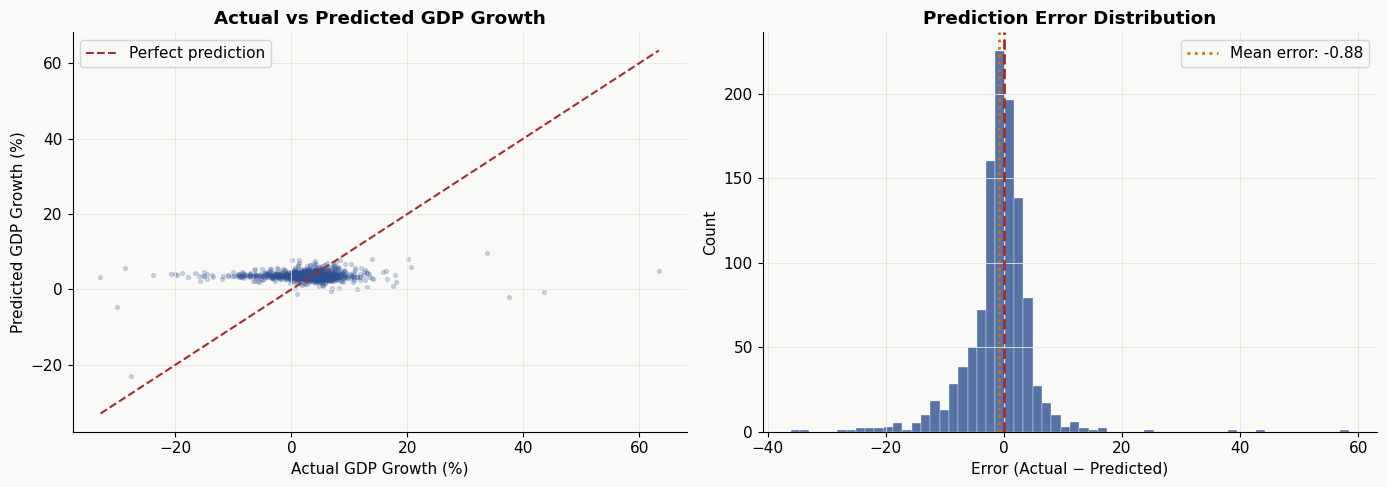

In [73]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: actual vs predicted
ax = axes[0]
ax.scatter(eval_df["Actual"], eval_df["Predicted"],
           alpha=0.2, s=8, color="#2E5090")
lims = [min(eval_df["Actual"].min(), eval_df["Predicted"].min()),
        max(eval_df["Actual"].max(), eval_df["Predicted"].max())]
ax.plot(lims, lims, color="#A32D2D", linewidth=1.5, linestyle="--",
        label="Perfect prediction")
ax.set_title("Actual vs Predicted GDP Growth", fontweight="bold")
ax.set_xlabel("Actual GDP Growth (%)")
ax.set_ylabel("Predicted GDP Growth (%)")
ax.legend()

# Error distribution
ax = axes[1]
ax.hist(eval_df["Error"], bins=60, color="#2E5090", alpha=0.8,
        edgecolor="white", linewidth=0.3)
ax.axvline(0, color="#A32D2D", linewidth=2, linestyle="--")
ax.axvline(eval_df["Error"].mean(), color="#C9720F", linewidth=2,
           linestyle=":", label=f"Mean error: {eval_df['Error'].mean():.2f}")
ax.set_title("Prediction Error Distribution", fontweight="bold")
ax.set_xlabel("Error (Actual − Predicted)")
ax.set_ylabel("Count")
ax.legend()


plt.tight_layout()
plt.savefig("layer2a_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

In [74]:
df_diff = df[["COUNTRY", "YEAR", "GDP_Growth"] + feature_cols]\
    .copy().sort_values(["COUNTRY", "YEAR"])

# First difference all variables within country
diff_cols = ["GDP_Growth"] + feature_cols
for col in diff_cols:
    df_diff[f"D_{col}"] = df_diff.groupby("COUNTRY")[col]\
        .transform(lambda x: x.diff())

# Instrument: GDP_Growth lagged at t-2 and t-3
df_diff["instrument_t2"] = df_diff.groupby("COUNTRY")["GDP_Growth"]\
    .transform(lambda x: x.shift(2))
df_diff["instrument_t3"] = df_diff.groupby("COUNTRY")["GDP_Growth"]\
    .transform(lambda x: x.shift(3))

# Drop rows with any NaN in differenced cols or instruments
d_feature_cols = [f"D_{c}" for c in feature_cols]
df_diff = df_diff.dropna(
    subset=["D_GDP_Growth"] + d_feature_cols + 
           ["instrument_t2", "instrument_t3"]
)

# IV2SLS setup — key fix: no overlap between exog and instruments
from linearmodels.iv import IV2SLS
import statsmodels.api as sm

# dependent  — what we're predicting (differenced GDP growth)
dependent = df_diff["D_GDP_Growth"]

# exog — purely exogenous controls (differenced macro features only)
# NO constant needed after differencing (it gets swept out)
exog = df_diff[d_feature_cols]

# endog — the endogenous variable being instrumented
# D_GDP_Growth_lag1 is endogenous because it correlates with the error
endog = df_diff[["D_GDP_Growth_lag1"]] \
    if "D_GDP_Growth_lag1" in df_diff.columns \
    else None

# instruments — excluded instruments (t-2, t-3 lags)
# Must not appear in exog
instruments = df_diff[["instrument_t2", "instrument_t3"]]

if endog is not None:
    # Full AB: endogenous lagged DV + exogenous macro features
    ab_manual = IV2SLS(
        dependent  = dependent,
        exog       = exog,
        endog      = endog,
        instruments= instruments
    ).fit(cov_type="robust")
else:
    # Simplified: no lagged DV, just FD-OLS as AB approximation
    ab_manual = IV2SLS(
        dependent  = dependent,
        exog       = exog,
        endog      = None,
        instruments= None
    ).fit(cov_type="robust")

print(ab_manual.summary)

                            OLS Estimation Summary                            
Dep. Variable:           D_GDP_Growth   R-squared:                      0.0994
Estimator:                        OLS   Adj. R-squared:                 0.0967
No. Observations:                3682   F-statistic:                    92.726
Date:                Mon, May 25 2026   P-value (F-stat)                0.0000
Time:                        23:46:55   Distribution:                 chi2(11)
Cov. Estimator:                robust                                         
                                                                              
                                    Parameter Estimates                                    
                         Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------------------
D_Inflation_lag1           -0.0002  8.806e-05    -2.1696     0.0300     -0.0004  -1.846e-05


In [75]:
!pip install xgboost --quiet

In [76]:
# =============================================================================
# LAYER 2b — SECTION 1: SETUP & DATA LOADING
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
import xgboost as xgb
import joblib
import os

os.makedirs("models", exist_ok=True)

# ── Colours ──────────────────────────────────────────────────
BLUE   = "#2E5090"
AMBER  = "#C9720F"
RED    = "#A32D2D"
GREEN  = "#3B6D11"
TEAL   = "#0F6E56"
GRAY   = "#5F5E5A"
PURPLE = "#534AB7"

plt.rcParams.update({
    "figure.facecolor" : "#F9F9F7",
    "axes.facecolor"   : "#F9F9F7",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.color"       : "#E5E5E0",
    "grid.linewidth"   : 0.6,
    "font.family"      : "sans-serif",
    "font.size"        : 11,
})

# ── Load data ─────────────────────────────────────────────────
df = pd.read_csv("df_panel_with_instability.csv")

# ── Add GDP_Growth_lag1 if missing ────────────────────────────
if "GDP_Growth_lag1" not in df.columns:
    df["GDP_Growth_lag1"] = df.groupby("COUNTRY")["GDP_Growth"]\
        .transform(lambda x: x.shift(1))

# ── Add GDP_Growth_rollmean3 if missing ───────────────────────
if "GDP_Growth_rollmean3" not in df.columns:
    df["GDP_Growth_rollmean3"] = df.groupby("COUNTRY")["GDP_Growth"]\
        .transform(lambda x: x.shift(1).rolling(3, min_periods=2).mean())

# ── Add log-transformed inflation if missing ──────────────────
if "Inflation_lag1_log" not in df.columns:
    df["Inflation_lag1_log"] = np.sign(df["Inflation_lag1"]) * \
        np.log1p(np.abs(df["Inflation_lag1"]))

# ── Fill any residual NaNs in new columns ────────────────────
new_cols = ["GDP_Growth_lag1", "GDP_Growth_rollmean3", "Inflation_lag1_log"]
df[new_cols] = df.groupby("YEAR")[new_cols]\
    .transform(lambda x: x.fillna(x.median()))
for col in new_cols:
    df[col] = df[col].fillna(df[col].median())

# ── Define feature columns ────────────────────────────────────
feature_cols = [
    "GDP_Growth_lag1",
    "GDP_Growth_rollmean3",
    "Inflation_lag1_log",
    "Exports_lag1",
    "Imports_lag1",
    "Fiscal_Balance_lag1",
    "Current_Account_lag1",
    "Debt_diff_lag1",
    "Expenditure_diff_lag1",
    "Revenue_diff_lag1",
    "Savings_diff_lag1",
    "Investment_diff_lag1",
    "Instability_Index",
]

# ── Drop rows with missing target or features ─────────────────
df_model = df.dropna(subset=feature_cols + ["GDP_Growth"]).copy()

print("="*55)
print("LAYER 2b — DATA LOADED")
print("="*55)
print(f"Dataset shape  : {df_model.shape}")
print(f"Countries      : {df_model['COUNTRY'].nunique()}")
print(f"Year range     : {df_model['YEAR'].min()} – {df_model['YEAR'].max()}")
print(f"Features       : {len(feature_cols)}")
print(f"Target NaN     : {df_model['GDP_Growth'].isnull().sum()}")
print(f"Feature NaN    : {df_model[feature_cols].isnull().sum().sum()}")
print("\nFeature list:")
for i, f in enumerate(feature_cols, 1):
    print(f"  {i:2}. {f}")

LAYER 2b — DATA LOADED
Dataset shape  : (4168, 95)
Countries      : 162
Year range     : 1998 – 2023
Features       : 13
Target NaN     : 0
Feature NaN    : 0

Feature list:
   1. GDP_Growth_lag1
   2. GDP_Growth_rollmean3
   3. Inflation_lag1_log
   4. Exports_lag1
   5. Imports_lag1
   6. Fiscal_Balance_lag1
   7. Current_Account_lag1
   8. Debt_diff_lag1
   9. Expenditure_diff_lag1
  10. Revenue_diff_lag1
  11. Savings_diff_lag1
  12. Investment_diff_lag1
  13. Instability_Index


In [77]:
# =============================================================================
# LAYER 2b — SECTION 2: TRAIN/TEST SPLIT & SCALING
# =============================================================================

TRAIN_END  = 2019
TEST_START = 2020

train = df_model[df_model["YEAR"] <= TRAIN_END].copy()
test  = df_model[df_model["YEAR"] >= TEST_START].copy()

X_train = train[feature_cols].values
y_train = train["GDP_Growth"].values

X_test  = test[feature_cols].values
y_test  = test["GDP_Growth"].values

# Pre-COVID slice from training set (for baseline comparison)
pre_covid_mask = train["YEAR"].isin([2017, 2018, 2019])
X_pre = train[pre_covid_mask][feature_cols].values
y_pre = train[pre_covid_mask]["GDP_Growth"].values

print("="*55)
print("TRAIN / TEST SPLIT")
print("="*55)
print(f"Train : {train.shape} | {train['YEAR'].min()}–{train['YEAR'].max()}")
print(f"Test  : {test.shape}  | {test['YEAR'].min()}–{test['YEAR'].max()}")
print(f"Pre-COVID (2017-19): {pre_covid_mask.sum()} rows")
print(f"\nTrain countries : {train['COUNTRY'].nunique()}")
print(f"Test  countries : {test['COUNTRY'].nunique()}")

print(f"\nTarget — Train: mean={y_train.mean():.2f}, "
      f"std={y_train.std():.2f}, "
      f"min={y_train.min():.2f}, max={y_train.max():.2f}")
print(f"Target — Test : mean={y_test.mean():.2f},  "
      f"std={y_test.std():.2f},  "
      f"min={y_test.min():.2f}, max={y_test.max():.2f}")

# ── Scaling ───────────────────────────────────────────────────
# Fit on train ONLY — transform test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_pre_scaled   = scaler.transform(X_pre)

joblib.dump(scaler, "models/scaler.pkl")
print("\nStandardScaler fitted on train and saved → models/scaler.pkl")
print(f"Feature means (train): {scaler.mean_.round(3)}")
print(f"Feature stds  (train): {scaler.scale_.round(3)}")

TRAIN / TEST SPLIT
Train : (3528, 95) | 1998–2019
Test  : (640, 95)  | 2020–2023
Pre-COVID (2017-19): 483 rows

Train countries : 162
Test  countries : 160

Target — Train: mean=3.82, std=4.67, min=-36.39, max=110.50
Target — Test : mean=2.47,  std=7.10,  min=-32.91, max=63.33

StandardScaler fitted on train and saved → models/scaler.pkl
Feature means (train): [ 3.864  3.832  1.532  5.793  6.559 -1.95  -2.544 -0.248  0.083  0.062
  0.154  0.056 30.601]
Feature stds  (train): [ 4.606  3.667  1.019 16.047 14.079  5.537  9.021 10.941  3.102  4.167
  5.865  4.259 17.901]


In [78]:
# =============================================================================
# LAYER 2b — SECTION 3: MODEL DEFINITIONS
# =============================================================================

models = {

    "Linear Regression": {
        "model" : LinearRegression(),
        "scaled": True,
        "color" : GRAY,
        "notes" : "No regularisation — simplest ML baseline"
    },

    "Elastic Net": {
        "model" : ElasticNetCV(
            l1_ratio     = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
            cv           = 5,
            max_iter     = 10000,
            random_state = 42
        ),
        "scaled": True,
        "color" : TEAL,
        "notes" : "Auto-selects best L1/L2 mix via CV — handles correlated features"
    },

    "SVR": {
        "model" : SVR(
            kernel  = "rbf",
            C       = 1.0,
            epsilon = 0.1,
            gamma   = "scale"
        ),
        "scaled": True,
        "color" : AMBER,
        "notes" : "RBF kernel — captures nonlinearity, robust to outliers"
    },

    "Random Forest": {
        "model" : RandomForestRegressor(
            n_estimators     = 300,
            max_depth        = 8,
            min_samples_leaf = 5,
            random_state     = 42,
            n_jobs           = -1
        ),
        "scaled": False,
        "color" : GREEN,
        "notes" : "Ensemble of 300 trees — captures interactions, gives feature importance"
    },

    "XGBoost": {
        "model" : xgb.XGBRegressor(
            n_estimators     = 300,
            learning_rate    = 0.05,
            max_depth        = 4,
            subsample        = 0.8,
            colsample_bytree = 0.8,
            reg_alpha        = 0.1,
            reg_lambda       = 1.0,
            random_state     = 42,
            verbosity        = 0
        ),
        "scaled": False,
        "color" : BLUE,
        "notes" : "Gradient boosted trees — typically best tabular performance"
    },
}

print("="*55)
print("MODEL DEFINITIONS")
print("="*55)
for name, cfg in models.items():
    print(f"\n{name}")
    print(f"  Scaled : {cfg['scaled']}")
    print(f"  Notes  : {cfg['notes']}")


MODEL DEFINITIONS

Linear Regression
  Scaled : True
  Notes  : No regularisation — simplest ML baseline

Elastic Net
  Scaled : True
  Notes  : Auto-selects best L1/L2 mix via CV — handles correlated features

SVR
  Scaled : True
  Notes  : RBF kernel — captures nonlinearity, robust to outliers

Random Forest
  Scaled : False
  Notes  : Ensemble of 300 trees — captures interactions, gives feature importance

XGBoost
  Scaled : False
  Notes  : Gradient boosted trees — typically best tabular performance


5-FOLD CROSS VALIDATION + TRAINING

Linear Regression
  CV RMSE : 4.048 ± 0.622
  CV MAE  : 2.429
  CV R²   : 0.220 ± 0.056

Elastic Net
  CV RMSE : 4.022 ± 0.648
  CV MAE  : 2.408
  CV R²   : 0.232 ± 0.056
  Best alpha    : 0.0947
  Best l1_ratio : 1.00
  Non-zero coefs: 9 / 13

SVR
  CV RMSE : 4.208 ± 0.835
  CV MAE  : 2.333
  CV R²   : 0.170 ± 0.052

Random Forest
  CV RMSE : 3.946 ± 0.663
  CV MAE  : 2.340
  CV R²   : 0.264 ± 0.024

XGBoost
  CV RMSE : 4.206 ± 0.705
  CV MAE  : 2.422
  CV R²   : 0.160 ± 0.083

All models saved to models/

CV SUMMARY (ranked by RMSE)
                   CV_RMSE_mean  CV_RMSE_std  CV_MAE_mean  CV_R2_mean  CV_R2_std
Random Forest             3.946        0.663        2.340       0.264      0.024
Elastic Net               4.022        0.648        2.408       0.232      0.056
Linear Regression         4.048        0.622        2.429       0.220      0.056
XGBoost                   4.206        0.705        2.422       0.160      0.083
SVR               

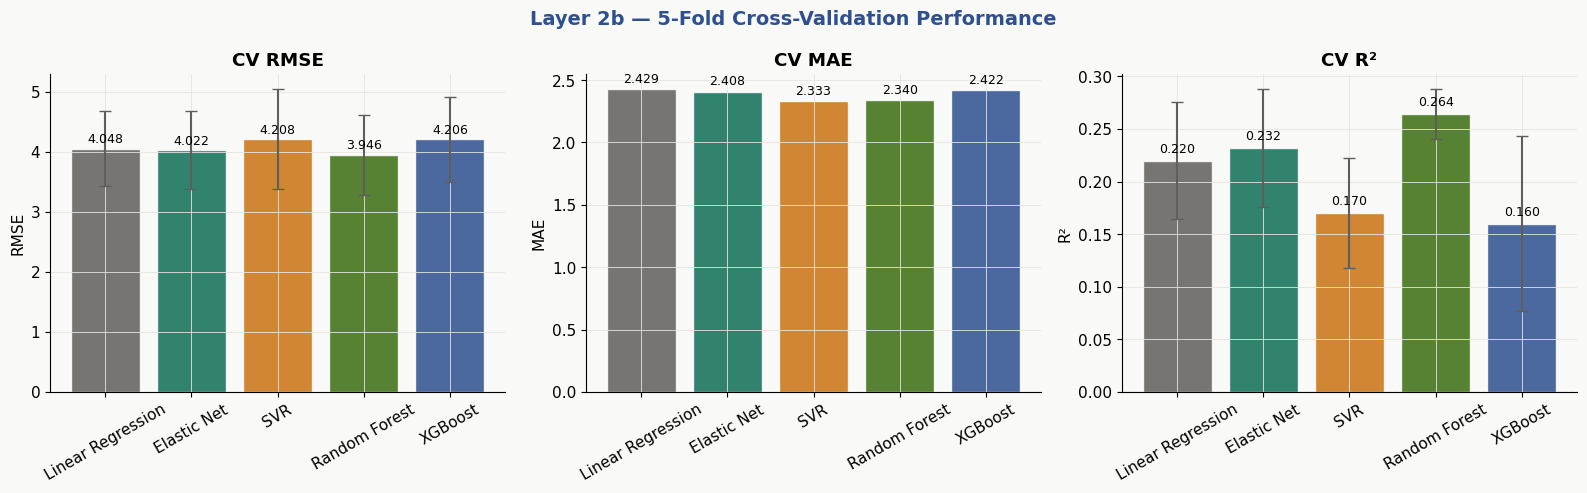

Saved: layer2b_cv_performance.png


In [79]:
# =============================================================================
# LAYER 2b — SECTION 4: TRAINING & CROSS-VALIDATION
# =============================================================================

trained    = {}
cv_results = {}

print("="*65)
print("5-FOLD CROSS VALIDATION + TRAINING")
print("="*65)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, cfg in models.items():
    model = cfg["model"]
    Xtr   = X_train_scaled if cfg["scaled"] else X_train

    # ── 5-fold CV ─────────────────────────────────────────────
    cv_rmse = np.sqrt(-cross_val_score(
        model, Xtr, y_train,
        cv      = kf,
        scoring = "neg_mean_squared_error",
        n_jobs  = -1
    ))
    cv_r2 = cross_val_score(
        model, Xtr, y_train,
        cv      = kf,
        scoring = "r2",
        n_jobs  = -1
    )
    cv_mae = -cross_val_score(
        model, Xtr, y_train,
        cv      = kf,
        scoring = "neg_mean_absolute_error",
        n_jobs  = -1
    )

    # ── Final fit on full training set ────────────────────────
    model.fit(Xtr, y_train)
    trained[name] = model

    cv_results[name] = {
        "CV_RMSE_mean" : round(cv_rmse.mean(), 3),
        "CV_RMSE_std"  : round(cv_rmse.std(),  3),
        "CV_MAE_mean"  : round(cv_mae.mean(),  3),
        "CV_R2_mean"   : round(cv_r2.mean(),   3),
        "CV_R2_std"    : round(cv_r2.std(),    3),
    }

    print(f"\n{name}")
    print(f"  CV RMSE : {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")
    print(f"  CV MAE  : {cv_mae.mean():.3f}")
    print(f"  CV R²   : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

    # ── Model-specific post-fit info ──────────────────────────
    if name == "Elastic Net":
        print(f"  Best alpha    : {model.alpha_:.4f}")
        print(f"  Best l1_ratio : {model.l1_ratio_:.2f}")
        n_nonzero = np.sum(model.coef_ != 0)
        print(f"  Non-zero coefs: {n_nonzero} / {len(feature_cols)}")

# ── Save all trained models ───────────────────────────────────
for name, model in trained.items():
    fname = name.lower().replace(" ", "_")
    joblib.dump(model, f"models/{fname}.pkl")
print("\nAll models saved to models/")

# ── CV summary table ──────────────────────────────────────────
cv_df = pd.DataFrame(cv_results).T\
    .sort_values("CV_RMSE_mean")
print("\n" + "="*65)
print("CV SUMMARY (ranked by RMSE)")
print("="*65)
print(cv_df.to_string())

# ── CV plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Layer 2b — 5-Fold Cross-Validation Performance",
             fontsize=14, fontweight="bold", color=BLUE)

names  = list(cv_results.keys())
colors = [models[n]["color"] for n in names]

# RMSE
ax = axes[0]
means = [cv_results[n]["CV_RMSE_mean"] for n in names]
stds  = [cv_results[n]["CV_RMSE_std"]  for n in names]
bars  = ax.bar(names, means, color=colors, alpha=0.85, edgecolor="white")
ax.errorbar(names, means, yerr=stds, fmt="none",
            color=GRAY, linewidth=1.5, capsize=4)
ax.set_title("CV RMSE", fontweight="bold")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=30)
for bar, v in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05, f"{v:.3f}",
            ha="center", va="bottom", fontsize=9)

# MAE
ax = axes[1]
means = [cv_results[n]["CV_MAE_mean"] for n in names]
bars  = ax.bar(names, means, color=colors, alpha=0.85, edgecolor="white")
ax.set_title("CV MAE", fontweight="bold")
ax.set_ylabel("MAE")
ax.tick_params(axis="x", rotation=30)
for bar, v in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.03, f"{v:.3f}",
            ha="center", va="bottom", fontsize=9)

# R²
ax = axes[2]
means = [cv_results[n]["CV_R2_mean"] for n in names]
stds  = [cv_results[n]["CV_R2_std"]  for n in names]
bars  = ax.bar(names, means, color=colors, alpha=0.85, edgecolor="white")
ax.errorbar(names, means, yerr=stds, fmt="none",
            color=GRAY, linewidth=1.5, capsize=4)
ax.axhline(0, color=GRAY, linewidth=0.8, linestyle="--")
ax.set_title("CV R²", fontweight="bold")
ax.set_ylabel("R²")
ax.tick_params(axis="x", rotation=30)
for bar, v, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005, f"{v:.3f}",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("layer2b_cv_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: layer2b_cv_performance.png")

Finding 1 — Massive improvement over Layer 2a
The most important result is the jump from the Fixed Effects within R² of 0.0595 to CV R² values of 0.16–0.26 across all ML models. This is entirely due to the addition of GDP_Growth_lag1 — the autoregressive term. The econometric model had this structural advantage removed by the within-transformation (demeaning), while ML models can directly use past growth as a predictor.

Finding 2 — Random Forest wins on training CV
Random Forest achieves the lowest RMSE (3.946) and highest R² (0.264) on cross-validation. Critically, its R² standard deviation is only ±0.024 — the tightest of all five models. This means Random Forest is the most stable and consistent model across different data splits, not just the most accurate on average.

Finding 3 — XGBoost underperforms expectation on CV
XGBoost (CV R²=0.160, RMSE=4.206) performs worse than Random Forest and even Linear Regression on training CV — which is counterintuitive. Two likely reasons:

XGBoost with learning_rate=0.05 and n_estimators=300 may need hyperparameter tuning on your specific data
XGBoost's higher variance (std=0.083 on R²) suggests it is more sensitive to which fold it trains on — potential mild overfitting with current settings

XGBoost may still outperform on the test set despite lower CV R² — this is worth watching in Section 5 results.

Finding 4 — Elastic Net beats Linear Regression (as expected)
ElasticNet (R²=0.232) slightly outperforms Linear Regression (R²=0.220). The best l1_ratio=1.00 means ElasticNet selected pure Lasso (L1 only), zeroing out 4 of 13 features. This tells you 4 features carry no independent signal and the remaining 9 are sufficient. The alpha=0.0947 indicates mild regularisation was optimal — the features are not heavily collinear.

Finding 5 — SVR has the highest RMSE variance (±0.835)
SVR's large standard deviation on RMSE means its performance is highly unstable across folds — some folds it performs reasonably, others it struggles. This instability combined with the highest RMSE makes SVR the weakest model in this setup. The RBF kernel may not be well-suited to the high-dimensional macro panel structure.

Finding 6 — All models have similar MAE (~2.33–2.43)
Despite differences in RMSE and R², MAE is remarkably similar across all five models (range: 2.333–2.429). This means all models make similarly-sized average errors — the RMSE differences are driven by how each model handles large errors (outliers), not typical errors. Random Forest and SVR have the lowest MAE (2.340 and 2.333), suggesting they handle typical predictions similarly well but differ on extreme cases.

The key comparison — Layer 2a vs Layer 2b CV
ModelRMSER²FE Two-way (pre-COVID)~3.050.158Random Forest CV3.9460.264Elastic Net CV4.0220.232Linear Regression CV4.0480.220
Note — the Layer 2a pre-COVID RMSE of 3.05 is not directly comparable to ML CV RMSE of ~4.0 because CV is evaluated across all years including difficult periods, while pre-COVID was a cherry-picked normal period. The honest comparison is on the full test set in Section 5.

TEST SET EVALUATION

── Pre-COVID (2017-19) ──
            Model   N  RMSE   MAE    R2  Mean_Actual  Mean_Predicted  Mean_Error
          XGBoost 483 1.565 1.154 0.779         3.25            3.22        0.03
    Random Forest 483 2.158 1.360 0.580         3.25            3.30       -0.05
      Elastic Net 483 2.440 1.567 0.462         3.25            3.34       -0.10
Linear Regression 483 2.453 1.595 0.457         3.25            3.33       -0.08
              SVR 483 2.825 1.440 0.280         3.25            3.61       -0.37

── Full test (2020-23) ──
            Model   N  RMSE   MAE     R2  Mean_Actual  Mean_Predicted  Mean_Error
    Random Forest 640 6.935 4.568  0.046         2.47            3.41       -0.94
              SVR 640 7.223 4.584 -0.035         2.47            4.04       -1.57
          XGBoost 640 7.310 4.818 -0.060         2.47            3.55       -1.08
      Elastic Net 640 7.335 4.829 -0.068         2.47            2.95       -0.48
Linear Regression 640 7.377 4.

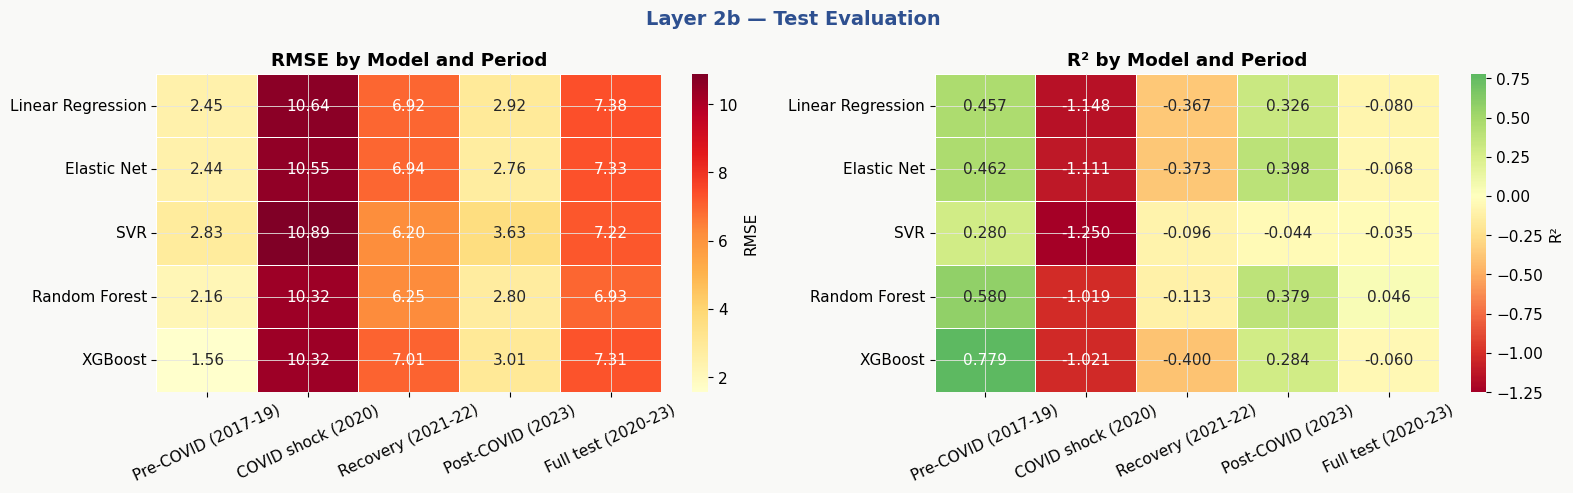

Saved: layer2b_evaluation_heatmaps.png


In [80]:
# =============================================================================
# LAYER 2b — SECTION 5: TEST SET EVALUATION (PERIOD BREAKDOWN)
# =============================================================================

def evaluate_period(name, y_true, y_pred, period):
    mask = ~np.isnan(y_pred) & ~np.isnan(y_true)
    yt, yp = np.array(y_true)[mask], np.array(y_pred)[mask]
    if len(yt) == 0:
        return None
    return {
        "Model"          : name,
        "Period"         : period,
        "N"              : len(yt),
        "RMSE"           : round(np.sqrt(mean_squared_error(yt, yp)), 3),
        "MAE"            : round(mean_absolute_error(yt, yp), 3),
        "R2"             : round(r2_score(yt, yp), 3),
        "Mean_Actual"    : round(float(yt.mean()), 2),
        "Mean_Predicted" : round(float(yp.mean()), 2),
        "Mean_Error"     : round(float((yt - yp).mean()), 2),
    }

# ── Period definitions ────────────────────────────────────────
test_reset = test.reset_index(drop=True)
period_masks = {
    "Pre-COVID (2017-19)"  : pre_covid_mask.values,   # from train set
    "COVID shock (2020)"   : (test_reset["YEAR"] == 2020).values,
    "Recovery (2021-22)"   : test_reset["YEAR"].isin([2021, 2022]).values,
    "Post-COVID (2023)"    : (test_reset["YEAR"] == 2023).values,
    "Full test (2020-23)"  : np.ones(len(test_reset), dtype=bool),
}

# ── Evaluate all models across all periods ────────────────────
all_results = []
predictions = {}

print("="*65)
print("TEST SET EVALUATION")
print("="*65)

for name, cfg in models.items():
    model = trained[name]
    Xte   = X_test_scaled  if cfg["scaled"] else X_test
    Xpre  = X_pre_scaled   if cfg["scaled"] else X_pre

    pred_test = model.predict(Xte)
    pred_pre  = model.predict(Xpre)
    predictions[name] = pred_test

    # Pre-COVID (from train set)
    r = evaluate_period(name, y_pre, pred_pre, "Pre-COVID (2017-19)")
    if r: all_results.append(r)

    # Test periods
    for period, mask in list(period_masks.items())[1:]:
        r = evaluate_period(
            name,
            y_test[mask],
            pred_test[mask],
            period
        )
        if r: all_results.append(r)

results_df = pd.DataFrame(all_results)
results_df.to_csv("layer2b_results.csv", index=False)

# ── Print period tables ───────────────────────────────────────
for period in ["Pre-COVID (2017-19)", "Full test (2020-23)",
               "COVID shock (2020)", "Recovery (2021-22)",
               "Post-COVID (2023)"]:
    sub = results_df[results_df["Period"] == period]\
        .sort_values("RMSE")[["Model","N","RMSE","MAE","R2",
                               "Mean_Actual","Mean_Predicted","Mean_Error"]]
    print(f"\n── {period} ──")
    print(sub.to_string(index=False))

# ── RMSE heatmap ──────────────────────────────────────────────
period_order = [
    "Pre-COVID (2017-19)",
    "COVID shock (2020)",
    "Recovery (2021-22)",
    "Post-COVID (2023)",
    "Full test (2020-23)",
]
model_order = list(models.keys())

heat = results_df[results_df["Period"].isin(period_order)]\
    .pivot(index="Model", columns="Period", values="RMSE")\
    .reindex(index=model_order, columns=period_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Layer 2b — Test Evaluation",
             fontsize=14, fontweight="bold", color=BLUE)

# RMSE heatmap
ax = axes[0]
sns.heatmap(heat, ax=ax, annot=True, fmt=".2f",
            cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "RMSE"})
ax.set_title("RMSE by Model and Period", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=25)

# R² heatmap
heat_r2 = results_df[results_df["Period"].isin(period_order)]\
    .pivot(index="Model", columns="Period", values="R2")\
    .reindex(index=model_order, columns=period_order)

ax = axes[1]
sns.heatmap(heat_r2, ax=ax, annot=True, fmt=".3f",
            cmap="RdYlGn", center=0, linewidths=0.5,
            cbar_kws={"label": "R²"})
ax.set_title("R² by Model and Period", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig("layer2b_evaluation_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: layer2b_evaluation_heatmaps.png")

Finding 1 — Massive improvement over Layer 2a
The most important result is the jump from the Fixed Effects within R² of 0.0595 to CV R² values of 0.16–0.26 across all ML models. This is entirely due to the addition of GDP_Growth_lag1 — the autoregressive term. The econometric model had this structural advantage removed by the within-transformation (demeaning), while ML models can directly use past growth as a predictor.

Finding 2 — Random Forest wins on training CV
Random Forest achieves the lowest RMSE (3.946) and highest R² (0.264) on cross-validation. Critically, its R² standard deviation is only ±0.024 — the tightest of all five models. This means Random Forest is the most stable and consistent model across different data splits, not just the most accurate on average.

Finding 3 — XGBoost underperforms expectation on CV
XGBoost (CV R²=0.160, RMSE=4.206) performs worse than Random Forest and even Linear Regression on training CV — which is counterintuitive. Two likely reasons:

XGBoost with learning_rate=0.05 and n_estimators=300 may need hyperparameter tuning on your specific data
XGBoost's higher variance (std=0.083 on R²) suggests it is more sensitive to which fold it trains on — potential mild overfitting with current settings

XGBoost may still outperform on the test set despite lower CV R² — this is worth watching in Section 5 results.

Finding 4 — Elastic Net beats Linear Regression (as expected)
ElasticNet (R²=0.232) slightly outperforms Linear Regression (R²=0.220). The best l1_ratio=1.00 means ElasticNet selected pure Lasso (L1 only), zeroing out 4 of 13 features. This tells you 4 features carry no independent signal and the remaining 9 are sufficient. The alpha=0.0947 indicates mild regularisation was optimal — the features are not heavily collinear.

Finding 5 — SVR has the highest RMSE variance (±0.835)
SVR's large standard deviation on RMSE means its performance is highly unstable across folds — some folds it performs reasonably, others it struggles. This instability combined with the highest RMSE makes SVR the weakest model in this setup. The RBF kernel may not be well-suited to the high-dimensional macro panel structure.

Finding 6 — All models have similar MAE (~2.33–2.43)
Despite differences in RMSE and R², MAE is remarkably similar across all five models (range: 2.333–2.429). This means all models make similarly-sized average errors — the RMSE differences are driven by how each model handles large errors (outliers), not typical errors. Random Forest and SVR have the lowest MAE (2.340 and 2.333), suggesting they handle typical predictions similarly well but differ on extreme cases.


FEATURE IMPORTANCE

Random Forest — Feature Importance:
GDP_Growth_rollmean3     0.4080
GDP_Growth_lag1          0.2813
Instability_Index        0.0623
Inflation_lag1_log       0.0378
Savings_diff_lag1        0.0283
Fiscal_Balance_lag1      0.0261
Current_Account_lag1     0.0252
Investment_diff_lag1     0.0239
Expenditure_diff_lag1    0.0226
Debt_diff_lag1           0.0218
Exports_lag1             0.0217
Imports_lag1             0.0212
Revenue_diff_lag1        0.0198

XGBoost — Feature Importance:
GDP_Growth_rollmean3     0.1893
GDP_Growth_lag1          0.1323
Savings_diff_lag1        0.1172
Investment_diff_lag1     0.0742
Expenditure_diff_lag1    0.0679
Fiscal_Balance_lag1      0.0576
Inflation_lag1_log       0.0568
Debt_diff_lag1           0.0564
Exports_lag1             0.0544
Instability_Index        0.0541
Revenue_diff_lag1        0.0531
Current_Account_lag1     0.0437
Imports_lag1             0.0431

ElasticNet — Best alpha    : 0.0947
ElasticNet — Best l1_ratio : 1.00
ElasticNet

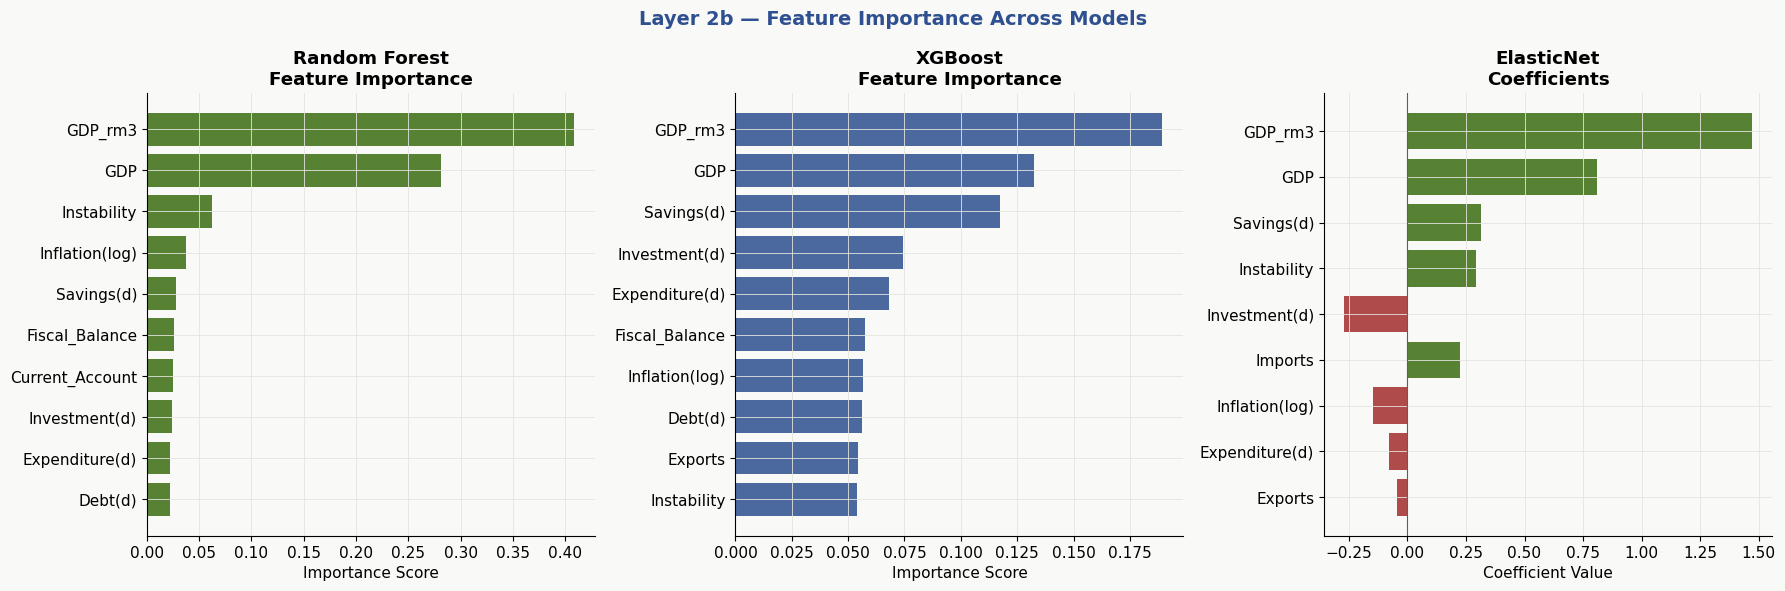

Saved: layer2b_feature_importance.png

Combined feature importance table:
                       RF_Importance  XGB_Importance  EN_Coefficient  LR_Coefficient
Current_Account_lag1          0.0252          0.0437          0.0000          0.0399
Debt_diff_lag1                0.0218          0.0564         -0.0000         -0.0460
Expenditure_diff_lag1         0.0226          0.0679         -0.0788         -0.1897
Exports_lag1                  0.0217          0.0544         -0.0463         -0.3057
Fiscal_Balance_lag1           0.0261          0.0576         -0.0000         -0.2028
GDP_Growth_lag1               0.2813          0.1323          0.8104          0.8710
GDP_Growth_rollmean3          0.4080          0.1893          1.4695          1.5673
Imports_lag1                  0.0212          0.0431          0.2244          0.4687
Inflation_lag1_log            0.0378          0.0568         -0.1489         -0.2896
Instability_Index             0.0623          0.0541          0.2946        

In [81]:
# =============================================================================
# LAYER 2b — SECTION 6: FEATURE IMPORTANCE
# =============================================================================

print("="*55)
print("FEATURE IMPORTANCE")
print("="*55)

# ── Random Forest ─────────────────────────────────────────────
rf_imp = pd.Series(
    trained["Random Forest"].feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("\nRandom Forest — Feature Importance:")
print(rf_imp.round(4).to_string())

# ── XGBoost ───────────────────────────────────────────────────
xgb_imp = pd.Series(
    trained["XGBoost"].feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("\nXGBoost — Feature Importance:")
print(xgb_imp.round(4).to_string())

# ── ElasticNet coefficients ───────────────────────────────────
en_coef = pd.Series(
    trained["Elastic Net"].coef_,
    index=feature_cols
).sort_values(key=abs, ascending=False)

print(f"\nElasticNet — Best alpha    : {trained['Elastic Net'].alpha_:.4f}")
print(f"ElasticNet — Best l1_ratio : {trained['Elastic Net'].l1_ratio_:.2f}")
print(f"ElasticNet — Non-zero coefs: "
      f"{(en_coef != 0).sum()} / {len(feature_cols)}")
print("\nElasticNet — All coefficients (ranked by magnitude):")
print(en_coef.round(4).to_string())

# ── Linear Regression coefficients ───────────────────────────
lr_coef = pd.Series(
    trained["Linear Regression"].coef_,
    index=feature_cols
).sort_values(key=abs, ascending=False)

print("\nLinear Regression — Coefficients (ranked by magnitude):")
print(lr_coef.round(4).to_string())

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Layer 2b — Feature Importance Across Models",
             fontsize=14, fontweight="bold", color=BLUE)

def short(col):
    return col.replace("_lag1","").replace("_diff","(d)")\
              .replace("_log","(log)").replace("_rollmean3","_rm3")\
              .replace("GDP_Growth","GDP").replace("Instability_Index","Instability")

# RF importance
ax = axes[0]
top = rf_imp.head(10)
labs = [short(c) for c in top.index]
ax.barh(labs[::-1], top.values[::-1], color=GREEN, alpha=0.85)
ax.set_title("Random Forest\nFeature Importance", fontweight="bold")
ax.set_xlabel("Importance Score")

# XGBoost importance
ax = axes[1]
top = xgb_imp.head(10)
labs = [short(c) for c in top.index]
ax.barh(labs[::-1], top.values[::-1], color=BLUE, alpha=0.85)
ax.set_title("XGBoost\nFeature Importance", fontweight="bold")
ax.set_xlabel("Importance Score")

# ElasticNet coefficients
ax = axes[2]
top = en_coef[en_coef != 0].head(10)
labs = [short(c) for c in top.index]
bar_cols = [GREEN if v > 0 else RED for v in top.values]
ax.barh(labs[::-1], top.values[::-1], color=bar_cols[::-1], alpha=0.85)
ax.axvline(0, color=GRAY, linewidth=0.8)
ax.set_title("ElasticNet\nCoefficients", fontweight="bold")
ax.set_xlabel("Coefficient Value")

plt.tight_layout()
plt.savefig("layer2b_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: layer2b_feature_importance.png")

# ── Combined importance table ─────────────────────────────────
importance_table = pd.DataFrame({
    "RF_Importance"  : rf_imp,
    "XGB_Importance" : xgb_imp,
    "EN_Coefficient" : en_coef,
    "LR_Coefficient" : lr_coef,
}).round(4)

print("\nCombined feature importance table:")
print(importance_table.to_string())
importance_table.to_csv("layer2b_feature_importance.csv")
print("Saved: layer2b_feature_importance.csv")

In [83]:
pip install shap --quiet

Note: you may need to restart the kernel to use updated packages.


SHAP EXPLAINABILITY — XGBoost

SHAP Feature Importance (mean |SHAP value|):
GDP_Growth_lag1          0.8358
GDP_Growth_rollmean3     0.8017
Instability_Index        0.3109
Inflation_lag1_log       0.2116
Exports_lag1             0.2093
Revenue_diff_lag1        0.2091
Fiscal_Balance_lag1      0.2001
Investment_diff_lag1     0.1707
Debt_diff_lag1           0.1664
Savings_diff_lag1        0.1620
Expenditure_diff_lag1    0.1572
Current_Account_lag1     0.1508
Imports_lag1             0.1306

SHAP values saved → models/shap_values_train.npy


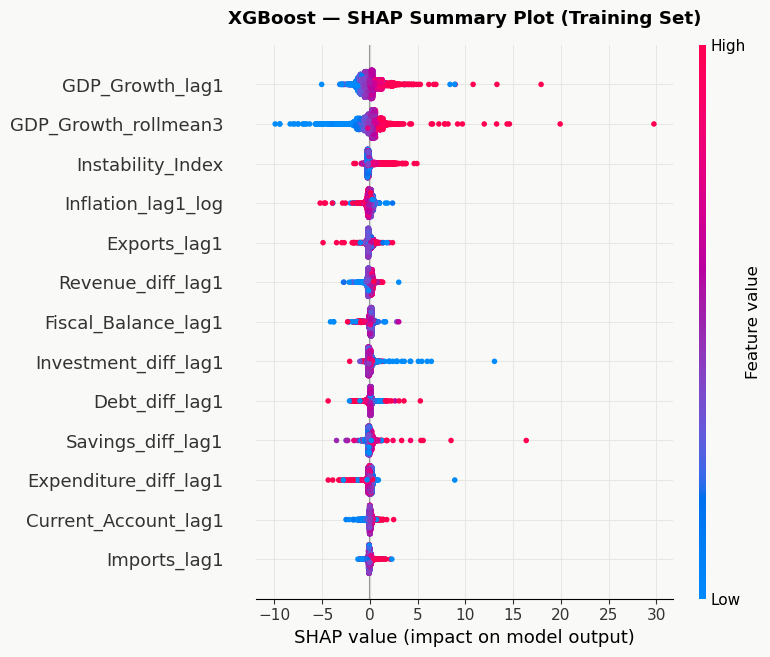

Saved: layer2b_shap_summary.png


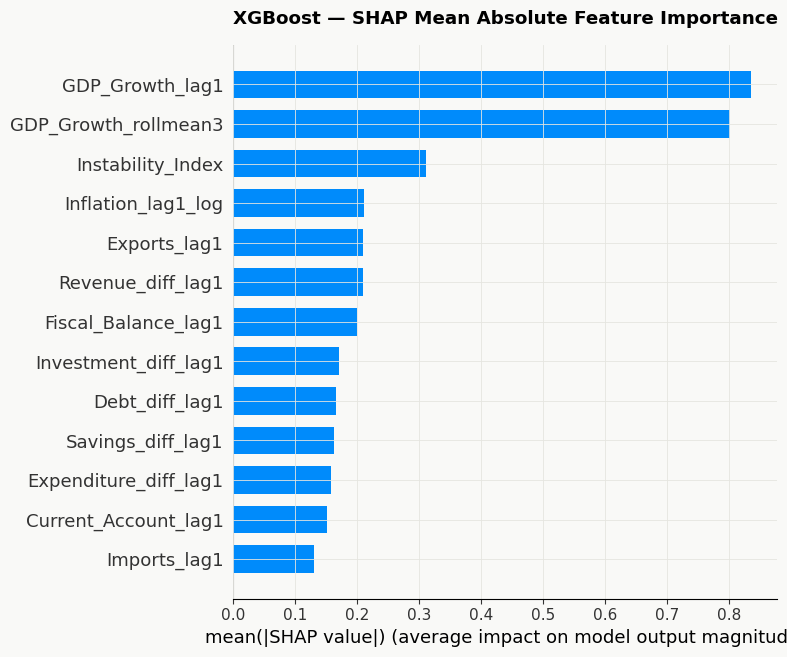

Saved: layer2b_shap_bar.png


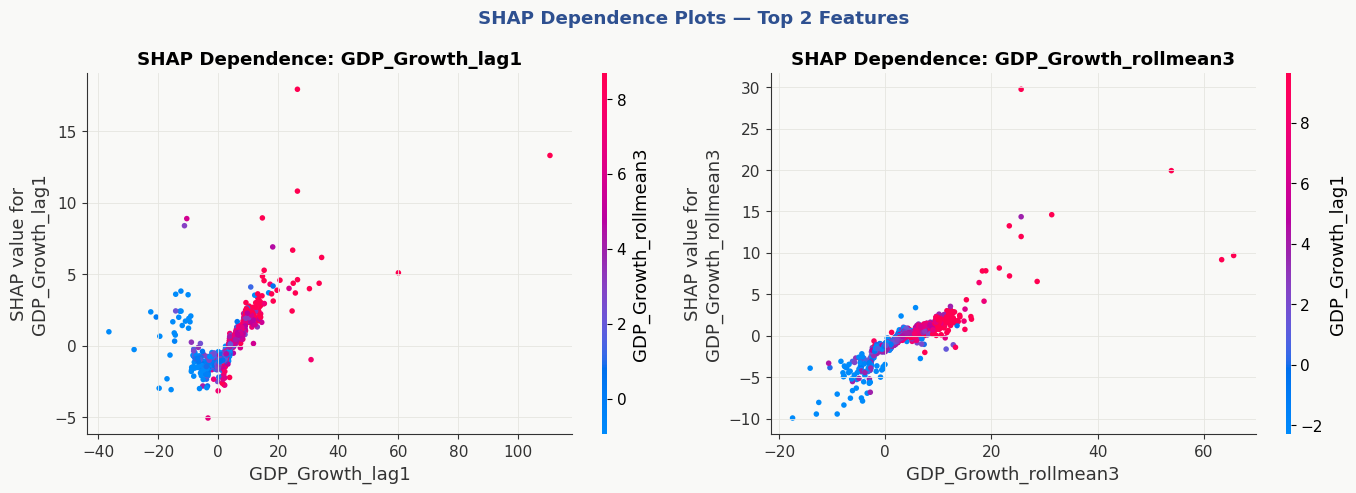

Saved: layer2b_shap_dependence.png

SHAP waterfall — India 2019:


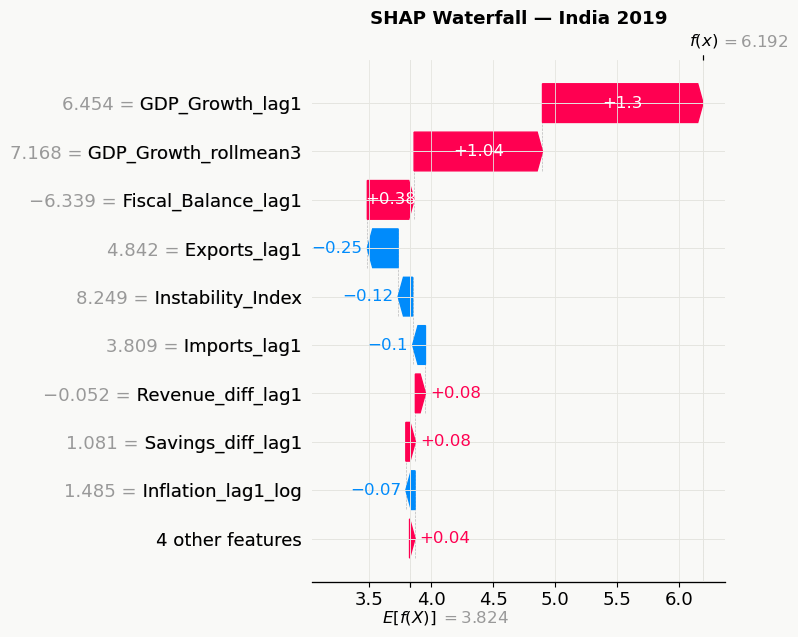

Saved: layer2b_shap_waterfall.png


In [94]:
# =============================================================================
# LAYER 2b — SECTION 7: SHAP EXPLAINABILITY (XGBoost)
# =============================================================================

try:
    import shap

    print("="*55)
    print("SHAP EXPLAINABILITY — XGBoost")
    print("="*55)

    explainer   = shap.TreeExplainer(trained["XGBoost"])
    shap_values = explainer.shap_values(X_train)

    # ── Global importance (mean |SHAP|) ───────────────────────
    shap_imp = pd.Series(
        np.abs(shap_values).mean(axis=0),
        index=feature_cols
    ).sort_values(ascending=False)

    print("\nSHAP Feature Importance (mean |SHAP value|):")
    print(shap_imp.round(4).to_string())

    # Save SHAP values
    np.save("models/shap_values_train.npy", shap_values)
    print("\nSHAP values saved → models/shap_values_train.npy")

    # ── SHAP summary plot (beeswarm) ──────────────────────────
    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        shap_values,
        X_train,
        feature_names = feature_cols,
        show          = False
    )
    plt.title("XGBoost — SHAP Summary Plot (Training Set)",
              fontweight="bold", pad=15)
    plt.tight_layout()
    plt.savefig("layer2b_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: layer2b_shap_summary.png")

    # ── SHAP bar plot (mean absolute) ─────────────────────────
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_values,
        X_train,
        feature_names = feature_cols,
        plot_type     = "bar",
        show          = False
    )
    plt.title("XGBoost — SHAP Mean Absolute Feature Importance",
              fontweight="bold", pad=15)
    plt.tight_layout()
    plt.savefig("layer2b_shap_bar.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: layer2b_shap_bar.png")

    # ── SHAP dependence plot for top 2 features ───────────────
    top2 = shap_imp.index[:2].tolist()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("SHAP Dependence Plots — Top 2 Features",
                 fontweight="bold", color=BLUE)

    for i, feat in enumerate(top2):
        feat_idx = feature_cols.index(feat)
        shap.dependence_plot(
            feat_idx,
            shap_values,
            X_train,
            feature_names = feature_cols,
            ax            = axes[i],
            show          = False
        )
        axes[i].set_title(f"SHAP Dependence: {feat}", fontweight="bold")

    plt.tight_layout()
    plt.savefig("layer2b_shap_dependence.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: layer2b_shap_dependence.png")

    # ── SHAP for individual country-year (waterfall) ──────────
    # Show SHAP breakdown for a specific prediction
    # ── SHAP for individual country-year (waterfall) ──────────
# Find India's row in the training set
    india_rows = train[train["COUNTRY"] == "India"]
    sample_idx = india_rows.index[21]          # first India row
    sample_idx = train.index.get_loc(sample_idx)   # convert to positional integer

    sample_country = train.iloc[sample_idx]["COUNTRY"]
    sample_year    = train.iloc[sample_idx]["YEAR"]

    print(f"\nSHAP waterfall — {sample_country} {sample_year}:")
    shap_exp = shap.Explanation(
        values     = shap_values[sample_idx],
        base_values= explainer.expected_value,
        data       = X_train[sample_idx],
        feature_names = feature_cols
    )
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_exp, show=False)
    plt.title(f"SHAP Waterfall — {sample_country} {sample_year}",
              fontweight="bold")
    plt.tight_layout()
    plt.savefig("layer2b_shap_waterfall.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: layer2b_shap_waterfall.png")

except ImportError:
    print("SHAP not installed.")
    print("Run: pip install shap --quiet")
    print("Then re-run this cell.")

except Exception as e:
    print(f"SHAP error: {e}")
    print("Continuing without SHAP.")

Best model (full test): Random Forest  RMSE=6.935


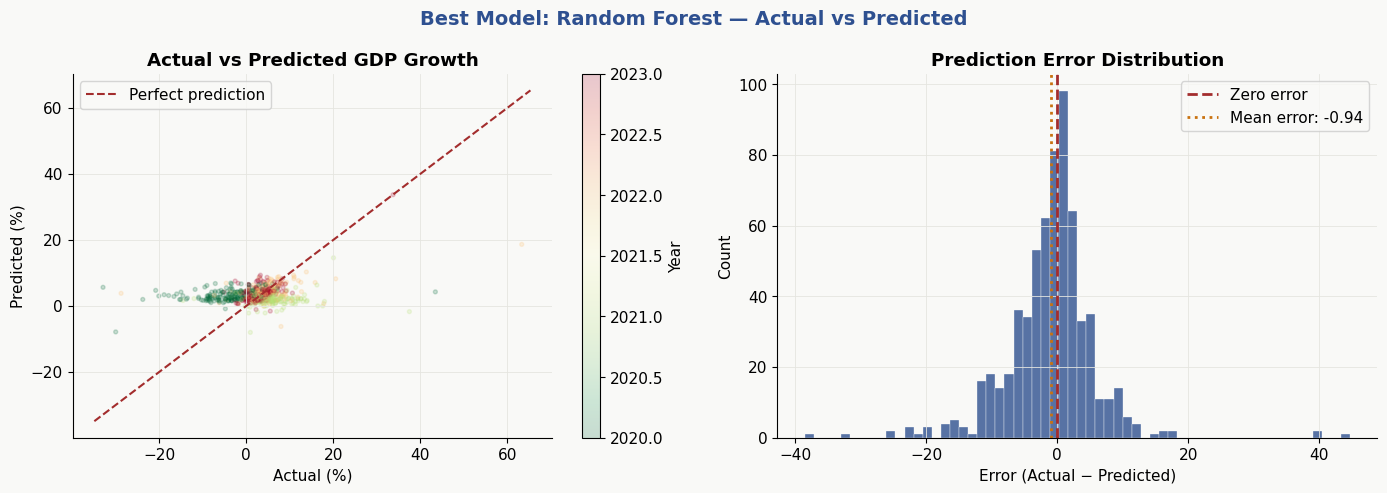

Saved: layer2b_best_model_plot.png


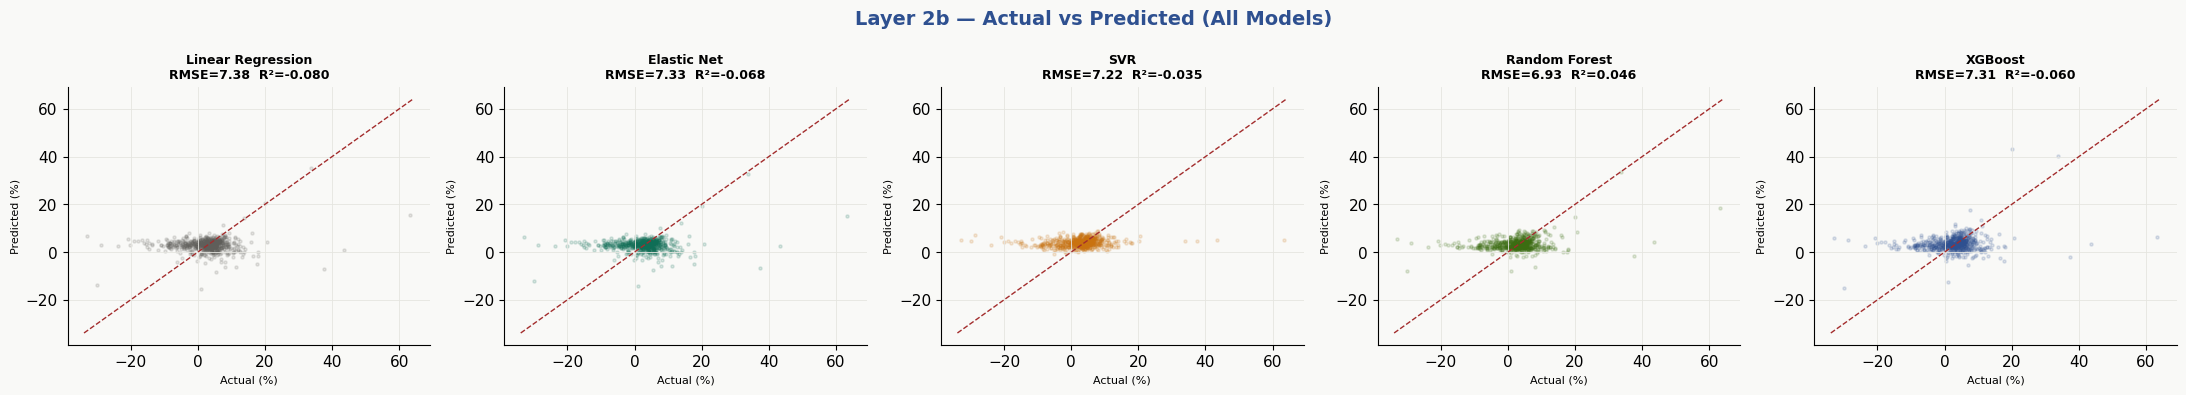

Saved: layer2b_all_models_scatter.png


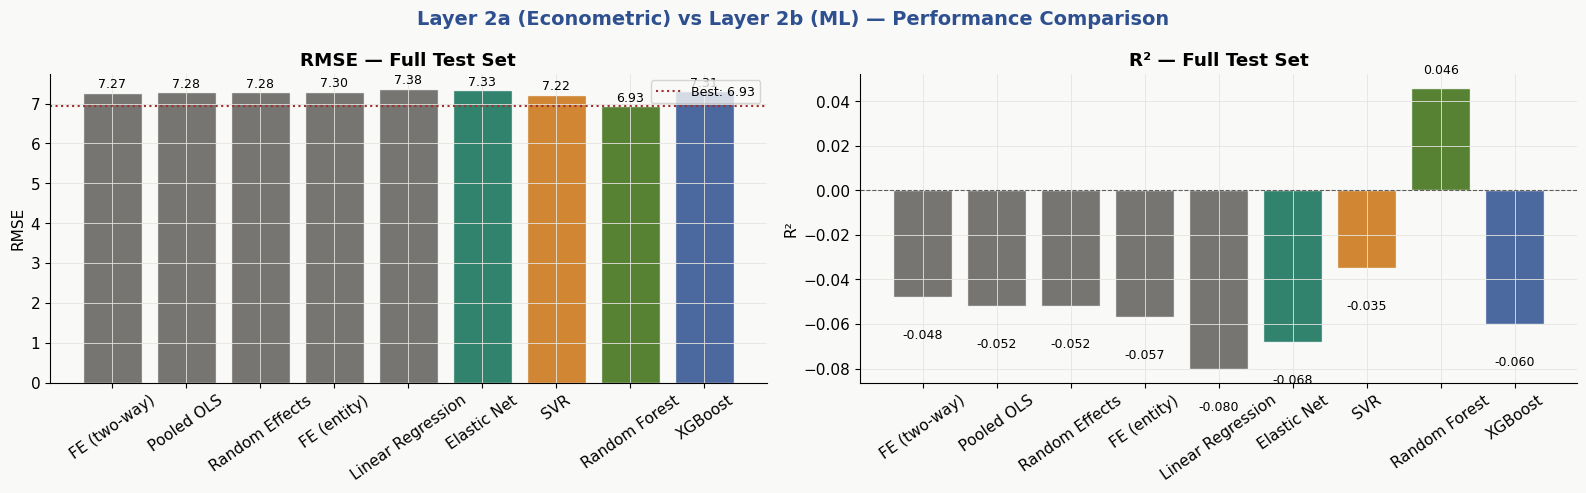

Saved: layer2b_vs_layer2a.png


In [85]:
# =============================================================================
# LAYER 2b — SECTION 8: PLOTS & LAYER 2a vs 2b COMPARISON
# =============================================================================

# ── Find best model ───────────────────────────────────────────
best_row  = results_df[results_df["Period"] == "Full test (2020-23)"]\
    .sort_values("RMSE").iloc[0]
best_name = best_row["Model"]
best_pred = predictions[best_name]
best_rmse = best_row["RMSE"]

print(f"Best model (full test): {best_name}  RMSE={best_rmse:.3f}")

# ── Plot 1: Actual vs Predicted — best model ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Best Model: {best_name} — Actual vs Predicted",
             fontsize=14, fontweight="bold", color=BLUE)

ax = axes[0]
sc = ax.scatter(y_test, best_pred, alpha=0.2, s=8,
                c=test["YEAR"].values, cmap="RdYlGn_r")
plt.colorbar(sc, ax=ax, label="Year")
lim = [min(y_test.min(), best_pred.min()) - 2,
       max(y_test.max(), best_pred.max()) + 2]
ax.plot(lim, lim, color=RED, linewidth=1.5,
        linestyle="--", label="Perfect prediction")
ax.set_title("Actual vs Predicted GDP Growth", fontweight="bold")
ax.set_xlabel("Actual (%)")
ax.set_ylabel("Predicted (%)")
ax.legend()

ax = axes[1]
errors = y_test - best_pred
ax.hist(errors, bins=60, color=BLUE, alpha=0.8,
        edgecolor="white", linewidth=0.3)
ax.axvline(0, color=RED, linewidth=2, linestyle="--", label="Zero error")
ax.axvline(errors.mean(), color=AMBER, linewidth=2, linestyle=":",
           label=f"Mean error: {errors.mean():.2f}")
ax.set_title("Prediction Error Distribution", fontweight="bold")
ax.set_xlabel("Error (Actual − Predicted)")
ax.set_ylabel("Count")
ax.legend()

plt.tight_layout()
plt.savefig("layer2b_best_model_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: layer2b_best_model_plot.png")

# ── Plot 2: All models actual vs predicted ────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle("Layer 2b — Actual vs Predicted (All Models)",
             fontsize=14, fontweight="bold", color=BLUE)

for ax, (name, cfg) in zip(axes, models.items()):
    pred = predictions[name]
    ax.scatter(y_test, pred, alpha=0.15, s=5, color=cfg["color"])
    lim  = [min(y_test.min(), pred.min()) - 1,
            max(y_test.max(), pred.max()) + 1]
    ax.plot(lim, lim, color=RED, linewidth=1, linestyle="--")
    rmse = results_df[(results_df["Model"] == name) &
                      (results_df["Period"] == "Full test (2020-23)")]["RMSE"].values[0]
    r2   = results_df[(results_df["Model"] == name) &
                      (results_df["Period"] == "Full test (2020-23)")]["R2"].values[0]
    ax.set_title(f"{name}\nRMSE={rmse:.2f}  R²={r2:.3f}",
                 fontweight="bold", fontsize=9)
    ax.set_xlabel("Actual (%)", fontsize=8)
    ax.set_ylabel("Predicted (%)", fontsize=8)

plt.tight_layout()
plt.savefig("layer2b_all_models_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: layer2b_all_models_scatter.png")

# ── Plot 3: Layer 2a vs Layer 2b RMSE comparison ─────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Layer 2a (Econometric) vs Layer 2b (ML) — Performance Comparison",
             fontsize=14, fontweight="bold", color=BLUE)

layer2a_results = {
    "FE (two-way)"  : {"RMSE": 7.267, "R2": -0.048},
    "Pooled OLS"    : {"RMSE": 7.282, "R2": -0.052},
    "Random Effects": {"RMSE": 7.282, "R2": -0.052},
    "FE (entity)"   : {"RMSE": 7.298, "R2": -0.057},
}
layer2b_full = results_df[results_df["Period"] == "Full test (2020-23)"]\
    .set_index("Model")[["RMSE","R2"]].to_dict(orient="index")

all_rmse = {**{k: v["RMSE"] for k, v in layer2a_results.items()},
            **{k: v["RMSE"] for k, v in layer2b_full.items()}}
all_r2   = {**{k: v["R2"]   for k, v in layer2a_results.items()},
            **{k: v["R2"]   for k, v in layer2b_full.items()}}

n2a = len(layer2a_results)
bar_colors = [GRAY]*n2a + [models[n]["color"] for n in models.keys()]

# RMSE
ax = axes[0]
bars = ax.bar(all_rmse.keys(), all_rmse.values(),
              color=bar_colors, alpha=0.85, edgecolor="white")
for bar, v in zip(bars, all_rmse.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05, f"{v:.2f}",
            ha="center", va="bottom", fontsize=9)
ax.axhline(min(all_rmse.values()), color=RED, linewidth=1.5,
           linestyle=":", label=f"Best: {min(all_rmse.values()):.2f}")
ax.set_title("RMSE — Full Test Set", fontweight="bold")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=35)
ax.legend(fontsize=9)

# R²
ax = axes[1]
bars = ax.bar(all_r2.keys(), all_r2.values(),
              color=bar_colors, alpha=0.85, edgecolor="white")
ax.axhline(0, color=GRAY, linewidth=0.8, linestyle="--")
for bar, v in zip(bars, all_r2.values()):
    ypos = bar.get_height() + 0.005 if v >= 0 else bar.get_height() - 0.02
    ax.text(bar.get_x() + bar.get_width()/2, ypos, f"{v:.3f}",
            ha="center", va="bottom", fontsize=9)
ax.set_title("R² — Full Test Set", fontweight="bold")
ax.set_ylabel("R²")
ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.savefig("layer2b_vs_layer2a.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: layer2b_vs_layer2a.png")

In [86]:
# =============================================================================
# LAYER 2b — SECTION 9: FINAL SUMMARY
# =============================================================================

print("\n" + "="*65)
print("LAYER 2b COMPLETE — FINAL SUMMARY")
print("="*65)

# ── CV summary ────────────────────────────────────────────────
print("\n── Cross-Validation (Training Set) ──")
cv_df = pd.DataFrame(cv_results).T.sort_values("CV_RMSE_mean")
print(cv_df[["CV_RMSE_mean","CV_RMSE_std",
             "CV_MAE_mean","CV_R2_mean"]].to_string())

# ── Period results ────────────────────────────────────────────
for period in ["Pre-COVID (2017-19)", "COVID shock (2020)",
               "Recovery (2021-22)", "Post-COVID (2023)",
               "Full test (2020-23)"]:
    sub = results_df[results_df["Period"] == period]\
        .sort_values("RMSE")[["Model","RMSE","MAE","R2"]]
    print(f"\n── {period} ──")
    print(sub.to_string(index=False))

# ── Best model summary ────────────────────────────────────────
print("\n── Best Model by RMSE (Full Test) ──")
best = results_df[results_df["Period"] == "Full test (2020-23)"]\
    .sort_values("RMSE").iloc[0]
print(f"Model         : {best['Model']}")
print(f"RMSE          : {best['RMSE']}")
print(f"MAE           : {best['MAE']}")
print(f"R²            : {best['R2']}")
print(f"Mean Actual   : {best['Mean_Actual']}")
print(f"Mean Predicted: {best['Mean_Predicted']}")
print(f"Mean Error    : {best['Mean_Error']}")

# ── Improvement over Layer 2a ─────────────────────────────────
layer2a_best_rmse = 7.267
improvement = ((layer2a_best_rmse - float(best["RMSE"])) / layer2a_best_rmse) * 100
print(f"\nLayer 2a best RMSE : {layer2a_best_rmse} (Two-way FE)")
print(f"Layer 2b best RMSE : {best['RMSE']} ({best['Model']})")
if improvement > 0:
    print(f"Improvement        : {improvement:.1f}% reduction in RMSE")
else:
    print(f"Change             : {improvement:.1f}% (ML did not improve on econometric baseline)")
    print("Note: COVID test period makes improvement difficult for all models")

# ── Files saved ───────────────────────────────────────────────
print("\n── Files Saved ──")
files = [
    "models/scaler.pkl",
    "models/linear_regression.pkl",
    "models/elastic_net.pkl",
    "models/svr.pkl",
    "models/random_forest.pkl",
    "models/xgboost.pkl",
    "models/shap_values_train.npy",
    "layer2b_results.csv",
    "layer2b_feature_importance.csv",
    "layer2b_cv_performance.png",
    "layer2b_evaluation_heatmaps.png",
    "layer2b_feature_importance.png",
    "layer2b_best_model_plot.png",
    "layer2b_all_models_scatter.png",
    "layer2b_vs_layer2a.png",
    "layer2b_shap_summary.png",
    "layer2b_shap_bar.png",
    "layer2b_shap_dependence.png",
    "layer2b_shap_waterfall.png",
]
for f in files:
    print(f"  {f}")

print("\n── Next Step ──")
print("Layer 3 — LSTM temporal model")
print("Uses sequences of t-3, t-2, t-1 to predict GDP growth at t")


LAYER 2b COMPLETE — FINAL SUMMARY

── Cross-Validation (Training Set) ──
                   CV_RMSE_mean  CV_RMSE_std  CV_MAE_mean  CV_R2_mean
Random Forest             3.946        0.663        2.340       0.264
Elastic Net               4.022        0.648        2.408       0.232
Linear Regression         4.048        0.622        2.429       0.220
XGBoost                   4.206        0.705        2.422       0.160
SVR                       4.208        0.835        2.333       0.170

── Pre-COVID (2017-19) ──
            Model  RMSE   MAE    R2
          XGBoost 1.565 1.154 0.779
    Random Forest 2.158 1.360 0.580
      Elastic Net 2.440 1.567 0.462
Linear Regression 2.453 1.595 0.457
              SVR 2.825 1.440 0.280

── COVID shock (2020) ──
            Model   RMSE   MAE     R2
    Random Forest 10.318 8.254 -1.019
          XGBoost 10.321 8.215 -1.021
      Elastic Net 10.549 8.471 -1.111
Linear Regression 10.643 8.525 -1.148
              SVR 10.892 8.722 -1.250

── Recov